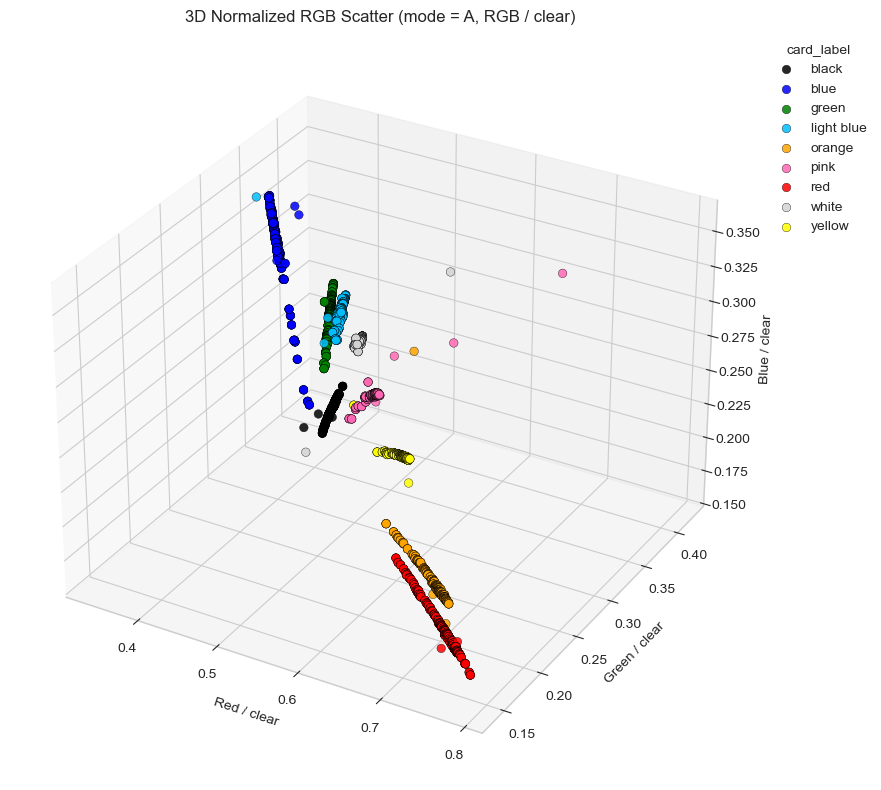

In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# --- Load from SQLite (v2 table) ---
db_path = "color_data/color_data.db"  # change path if your db is elsewhere
table = "colordata_v2"

with sqlite3.connect(db_path) as conn:
    df = pd.read_sql_query(
        f"""
        SELECT timestamp, mode, card_label, clear, red, green, blue
        FROM {table}
        WHERE mode = 'A'
        """,
        conn
    )

# --- Clean and ensure numeric values ---
cols = ["clear", "red", "green", "blue"]
df = df.dropna(subset=cols).copy()
for col in cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df = df.dropna(subset=cols)

# Avoid division issues: remove non-positive or extremely small clear values
min_clear = 50  # adjust if needed
df = df[df["clear"] >= min_clear].copy()

# Normalize RGB by clear (brightness)
df["r_norm"] = df["red"] / df["clear"]
df["g_norm"] = df["green"] / df["clear"]
df["b_norm"] = df["blue"] / df["clear"]

# Normalize label text for consistent mapping
df["card_label_norm"] = df["card_label"].astype(str).str.strip().str.lower()

# Map each label to a matching plot color
label_to_color = {
    "black": "black",
    "blue": "blue",
    "green": "green",
    "light blue": "deepskyblue",
    "light_blue": "deepskyblue",
    "orange": "orange",
    "pink": "hotpink",
    "red": "red",
    "white": "lightgray",
    "yellow": "yellow",
}

# --- Plot: 3D scatter of normalized RGB ---
plt.style.use("seaborn-v0_8-whitegrid")

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

labels = sorted(df["card_label_norm"].unique())
for label in labels:
    d = df[df["card_label_norm"] == label]
    c = label_to_color.get(label, "gray")
    ax.scatter(
        d["r_norm"], d["g_norm"], d["b_norm"],
        s=38,
        alpha=0.85,
        c=c,
        edgecolors="k",
        linewidths=0.3,
        depthshade=True,
        label=label
    )

ax.set_title("3D Normalized RGB Scatter (mode = A, RGB / clear)", pad=12)
ax.set_xlabel("Red / clear")
ax.set_ylabel("Green / clear")
ax.set_zlabel("Blue / clear")

ax.legend(title="card_label", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)

plt.tight_layout()
plt.show()

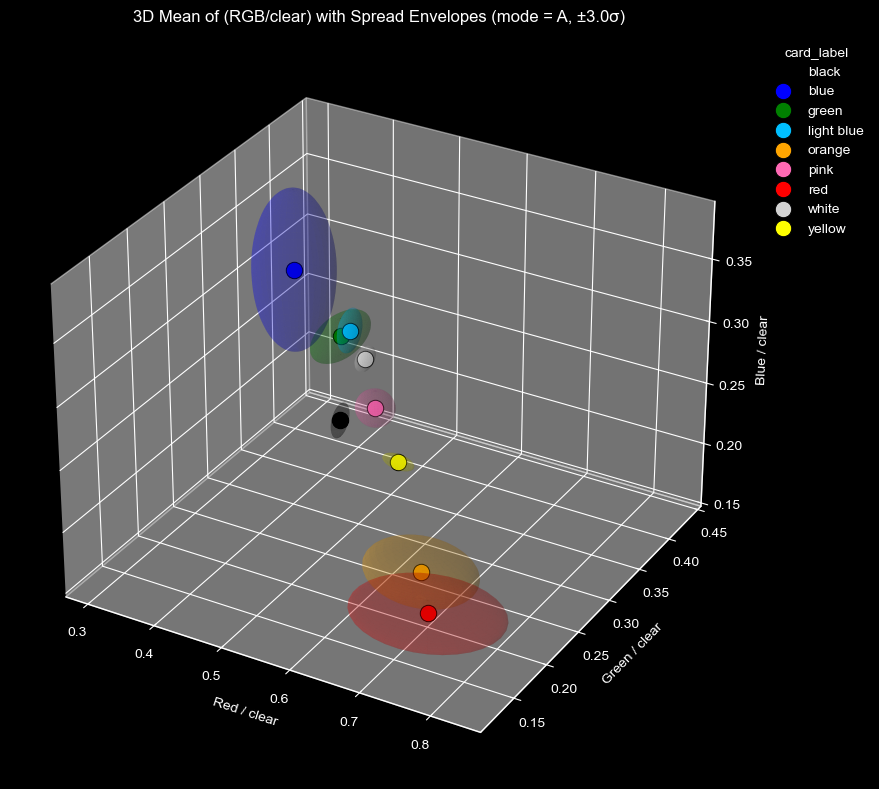

In [3]:
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load data (mode = 'A') from SQLite
db_path = "color_data/color_data.db"
with sqlite3.connect(db_path) as conn:
    df = pd.read_sql_query(
        """
       SELECT timestamp, mode, card_label, clear, red, green, blue
        FROM colordata_v2
        WHERE mode = 'A'
        """,
        conn
    )

# Clean and ensure numeric values
cols = ["clear", "red", "green", "blue"]
df = df.dropna(subset=cols).copy()
for col in cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df = df.dropna(subset=cols)

# Avoid division issues: remove non-positive or extremely small clear values
min_clear = 50  # adjust if needed after inspecting your sensor readings
df = df[df["clear"] >= min_clear].copy()

# Normalize RGB by clear (brightness)
df["r_norm"] = df["red"] / df["clear"]
df["g_norm"] = df["green"] / df["clear"]
df["b_norm"] = df["blue"] / df["clear"]

# Normalize label text for consistent mapping (e.g., "Yellow" vs "yellow")
df["card_label_norm"] = df["card_label"].astype(str).str.strip().str.lower()

# Map each label to a matching plot color
label_to_color = {
    "black": "black",
    "blue": "blue",
    "green": "green",
    "light blue": "deepskyblue",
    "light_blue": "deepskyblue",
    "orange": "orange",
    "pink": "hotpink",
    "red": "red",
    "white": "lightgray",
    "yellow": "yellow",
}

# Compute mean and std in the normalized space
stats = (
    df.groupby("card_label_norm")[["r_norm", "g_norm", "b_norm"]]
      .agg(["mean", "std", "count"])
)
stats.columns = ["_".join(c) for c in stats.columns]
stats = stats.reset_index()

def plot_std_ellipsoid(ax, center, radii, color, alpha=0.22, n=36):
    """
    Draw a 3D axis-aligned ellipsoid centered at `center` with radii `radii`.
    """
    u = np.linspace(0, 2*np.pi, n)
    v = np.linspace(0, np.pi, n)
    x = radii[0] * np.outer(np.cos(u), np.sin(v)) + center[0]
    y = radii[1] * np.outer(np.sin(u), np.sin(v)) + center[1]
    z = radii[2] * np.outer(np.ones_like(u), np.cos(v)) + center[2]
    ax.plot_surface(x, y, z, color=color, alpha=alpha, linewidth=0, shade=True)

# Theme: different look (dark)
plt.style.use("dark_background")
fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection="3d")

# Envelope scale: 1.0 = ±1 std; try 2.0 for a larger "range"
k_sigma = 3.0

for _, row in stats.iterrows():
    label = row["card_label_norm"]
    c = label_to_color.get(label, "gray")

    center = np.array([row["r_norm_mean"], row["g_norm_mean"], row["b_norm_mean"]], dtype=float)
    radii  = np.array([row["r_norm_std"],  row["g_norm_std"],  row["b_norm_std"]], dtype=float) * k_sigma

    # Mean point
    ax.scatter(center[0], center[1], center[2],
               s=140, c=c, edgecolors="k", linewidths=0.7, label=label)

    # Spread envelope (skip if std is invalid or too small)
    if np.all(np.isfinite(radii)) and np.all(radii > 0):
        plot_std_ellipsoid(ax, center, radii, c, alpha=0.20, n=34)

ax.set_title(f"3D Mean of (RGB/clear) with Spread Envelopes (mode = A, ±{k_sigma:.1f}σ)", pad=14)
ax.set_xlabel("Red / clear")
ax.set_ylabel("Green / clear")
ax.set_zlabel("Blue / clear")

ax.grid(True, linewidth=0.4, alpha=0.25)
ax.legend(title="card_label", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)

plt.tight_layout()
plt.show()

In [1]:
import sqlite3
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# -----------------------------
# 1) Train a decision tree model (0mm, mode=A)
# -----------------------------
db_path = "color_data/color_data.db"
with sqlite3.connect(db_path) as conn:
    df = pd.read_sql_query(
        """
         SELECT timestamp, mode, card_label, clear, red, green, blue
        FROM colordata_v2
        WHERE mode = 'A'
        """,
        conn
    )

df = df.dropna(subset=["clear", "red", "green", "blue"]).copy()
for col in ["clear", "red", "green", "blue"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df = df.dropna(subset=["clear", "red", "green", "blue"])

# You can tune this: higher => more conservative (more NO_CARD)
MIN_CLEAR = 80
df = df[df["clear"] >= MIN_CLEAR].copy()

# Normalize RGB by clear
df["r_norm"] = df["red"] / df["clear"]
df["g_norm"] = df["green"] / df["clear"]
df["b_norm"] = df["blue"] / df["clear"]

df["label"] = df["card_label"].astype(str).str.strip().str.lower()

X = df[["r_norm", "g_norm", "b_norm", "clear"]].to_numpy()
y = df["label"].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

clf = DecisionTreeClassifier(max_depth=6, min_samples_leaf=15, random_state=42)
clf.fit(X_train, y_train)

# -----------------------------
# 2) Build per-class range stats for rejection (in normalized space)
# -----------------------------
# Mean/std for r_norm,g_norm,b_norm for each class (trained labels)
stats = (
    df.groupby("label")[["r_norm", "g_norm", "b_norm"]]
      .agg(["mean", "std"])
)
stats.columns = ["_".join(c) for c in stats.columns]
stats = stats.reset_index()

# -----------------------------
# 3) Integer-only codegen (tree + range gate)
# -----------------------------
feature_names = ["r_norm", "g_norm", "b_norm", "clear"]
classes = clf.classes_.tolist()
class_to_id = {name: i for i, name in enumerate(classes)}

tree = clf.tree_
LEFT, RIGHT = tree.children_left, tree.children_right
FEATURE, THRESH, VALUE = tree.feature, tree.threshold, tree.value

SCALE = 100000  # fixed-point scale
K_SIGMA = 2.0   # You can tune this: smaller => stricter (more NO_CARD)

def node_is_leaf(n):
    return LEFT[n] == RIGHT[n]

def leaf_class_id(n):
    return int(np.argmax(VALUE[n][0]))

def enum_name(label):
    return "COLOR_" + label.upper().replace(" ", "_").replace("-", "_")

def emit_node_int(n, indent=2):
    sp = " " * indent
    if node_is_leaf(n):
        cid = leaf_class_id(n)
        return f"{sp}return {cid};\n"

    f_idx = int(FEATURE[n])
    thr = float(THRESH[n])

    if feature_names[f_idx] == "clear":
        s = ""
        s += f"{sp}if (C <= {int(round(thr))}u) {{\n"
        s += emit_node_int(int(LEFT[n]), indent + 2)
        s += f"{sp}}} else {{\n"
        s += emit_node_int(int(RIGHT[n]), indent + 2)
        s += f"{sp}}}\n"
        return s

    T = int(round(thr * SCALE))
    if feature_names[f_idx] == "r_norm":
        num = "R"
    elif feature_names[f_idx] == "g_norm":
        num = "G"
    else:
        num = "B"

    s = ""
    s += f"{sp}if (((uint64_t){num} * {SCALE}ULL) <= ((uint64_t){T}ULL * (uint64_t)C)) {{\n"
    s += emit_node_int(int(LEFT[n]), indent + 2)
    s += f"{sp}}} else {{\n"
    s += emit_node_int(int(RIGHT[n]), indent + 2)
    s += f"{sp}}}\n"
    return s

# Convert stats to fixed-point integers
# We will gate using: |x - mean| <= K_SIGMA * std  (all in fixed-point)
def to_fixed(x):
    return int(round(float(x) * SCALE))

# Build arrays aligned with class IDs
mean_r = [0]*len(classes)
mean_g = [0]*len(classes)
mean_b = [0]*len(classes)
std_r  = [0]*len(classes)
std_g  = [0]*len(classes)
std_b  = [0]*len(classes)

for _, row in stats.iterrows():
    label = row["label"]
    if label not in class_to_id:
        continue
    i = class_to_id[label]
    mean_r[i] = to_fixed(row["r_norm_mean"])
    mean_g[i] = to_fixed(row["g_norm_mean"])
    mean_b[i] = to_fixed(row["b_norm_mean"])
    # If std is NaN (too few samples), set to 0 to force rejection unless exactly equal
    std_r[i]  = to_fixed(row["r_norm_std"]) if np.isfinite(row["r_norm_std"]) else 0
    std_g[i]  = to_fixed(row["g_norm_std"]) if np.isfinite(row["g_norm_std"]) else 0
    std_b[i]  = to_fixed(row["b_norm_std"]) if np.isfinite(row["b_norm_std"]) else 0

# Emit C code
enum_lines = [f"  {enum_name(name)} = {i}," for name, i in class_to_id.items()]

c_code = ""
c_code += "/* Auto-generated fixed-point decision-tree color classifier with NO_CARD rejection */\n"


c_code += f"static const uint32_t MIN_CLEAR = {MIN_CLEAR}u;\n"
c_code += f"static const uint32_t SCALE = {SCALE}u;\n"
c_code += f"static const uint32_t K_SIGMA_X1000 = {int(round(K_SIGMA*1000))}u; /* K * 1000 */\n\n"

# Stats arrays
def emit_u32_array(name, arr):
    return "static const uint32_t " + name + "[] = {" + ", ".join(str(int(x)) for x in arr) + "};\n"

c_code += emit_u32_array("MEAN_R", mean_r)
c_code += emit_u32_array("MEAN_G", mean_g)
c_code += emit_u32_array("MEAN_B", mean_b)
c_code += emit_u32_array("STD_R",  std_r)
c_code += emit_u32_array("STD_G",  std_g)
c_code += emit_u32_array("STD_B",  std_b)
c_code += "\n"

c_code += "static inline uint32_t uabs_diff_u32(uint32_t a, uint32_t b) {\n"
c_code += "  return (a >= b) ? (a - b) : (b - a);\n"
c_code += "}\n\n"

c_code += "static inline int passes_range_gate(uint32_t rS, uint32_t gS, uint32_t bS, uint32_t cls) {\n"
c_code += "  /* Gate rule: |x-mean| <= K*std (fixed-point). Uses K_SIGMA_X1000 for integer math. */\n"
c_code += "  uint64_t k = (uint64_t)K_SIGMA_X1000;\n"
c_code += "  uint64_t thr_r = (k * (uint64_t)STD_R[cls]) / 1000ULL;\n"
c_code += "  uint64_t thr_g = (k * (uint64_t)STD_G[cls]) / 1000ULL;\n"
c_code += "  uint64_t thr_b = (k * (uint64_t)STD_B[cls]) / 1000ULL;\n"
c_code += "  if ((uint64_t)uabs_diff_u32(rS, MEAN_R[cls]) > thr_r) return 0;\n"
c_code += "  if ((uint64_t)uabs_diff_u32(gS, MEAN_G[cls]) > thr_g) return 0;\n"
c_code += "  if ((uint64_t)uabs_diff_u32(bS, MEAN_B[cls]) > thr_b) return 0;\n"
c_code += "  return 1;\n"
c_code += "}\n\n"

c_code += "static inline int tree_predict_class_id(uint32_t R, uint32_t G, uint32_t B, uint32_t C) {\n"
c_code += emit_node_int(0, indent=2)
c_code += "}\n\n"

print("Classes:", classes)
print("\n===== GENERATED INTEGER-ONLY C CODE (WITH NO_CARD REJECTION) =====\n")
print(c_code)

Classes: ['black', 'blue', 'green', 'light blue', 'orange', 'pink', 'red', 'white', 'yellow']

===== GENERATED INTEGER-ONLY C CODE (WITH NO_CARD REJECTION) =====

/* Auto-generated fixed-point decision-tree color classifier with NO_CARD rejection */
static const uint32_t MIN_CLEAR = 80u;
static const uint32_t SCALE = 100000u;
static const uint32_t K_SIGMA_X1000 = 2000u; /* K * 1000 */

static const uint32_t MEAN_R[] = {45713, 36092, 37749, 42469, 68137, 51436, 72686, 46071, 55081};
static const uint32_t MEAN_G[] = {31556, 34308, 39590, 36288, 20909, 31445, 17208, 35028, 30942};
static const uint32_t MEAN_B[] = {21920, 31501, 23981, 26667, 18444, 23992, 17807, 25465, 20280};
static const uint32_t STD_R[] = {142, 1887, 965, 353, 2630, 740, 3485, 324, 794};
static const uint32_t STD_G[] = {452, 1056, 1243, 548, 1104, 268, 1644, 429, 74};
static const uint32_t STD_B[] = {447, 2153, 503, 575, 716, 587, 336, 308, 220};

static inline uint32_t uabs_diff_u32(uint32_t a, uint32_t b) {
  return 

Change to elliptic distance (approximately Mahalanobis distance).

In [1]:
import sqlite3
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# -----------------------------
# 1) Train a decision tree model (mode=A)
# -----------------------------
db_path = "color_data/color_data.db"
with sqlite3.connect(db_path) as conn:
    df = pd.read_sql_query(
        """
        SELECT timestamp, mode, card_label, clear, red, green, blue
        FROM colordata_v2
        WHERE mode = 'A'
        """,
        conn
    )

df = df.dropna(subset=["clear", "red", "green", "blue"]).copy()
for col in ["clear", "red", "green", "blue"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df = df.dropna(subset=["clear", "red", "green", "blue"])

# Tune: higher => more conservative (more NO_CARD via MIN_CLEAR)
MIN_CLEAR = 80
df = df[df["clear"] >= MIN_CLEAR].copy()

# Normalize RGB by clear (float features for training)
df["r_norm"] = df["red"] / df["clear"]
df["g_norm"] = df["green"] / df["clear"]
df["b_norm"] = df["blue"] / df["clear"]

df["label"] = df["card_label"].astype(str).str.strip().str.lower()

X = df[["r_norm", "g_norm", "b_norm", "clear"]].to_numpy()
y = df["label"].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

clf = DecisionTreeClassifier(max_depth=6, min_samples_leaf=15, random_state=42)
clf.fit(X_train, y_train)

# -----------------------------
# 2) Per-class stats in normalized space for Mahalanobis-like gating
# -----------------------------
stats = (
    df.groupby("label")[["r_norm", "g_norm", "b_norm"]]
      .agg(["mean", "std"])
)
stats.columns = ["_".join(c) for c in stats.columns]
stats = stats.reset_index()

# -----------------------------
# 3) Integer-only codegen (tree + elliptical/Mahalanobis-like gate)
# -----------------------------
feature_names = ["r_norm", "g_norm", "b_norm", "clear"]
classes = clf.classes_.tolist()
class_to_id = {name: i for i, name in enumerate(classes)}

tree = clf.tree_
LEFT, RIGHT = tree.children_left, tree.children_right
FEATURE, THRESH, VALUE = tree.feature, tree.threshold, tree.value

SCALE = 100000            # fixed-point scale for rS,gS,bS = (X/C)*SCALE
K_SIGMA = 2.0             # intuitive "sigma" gate level (used to set MAHA threshold)
EPS_STD = 1               # minimum std (fixed-point units) to avoid division by zero

def node_is_leaf(n):
    return LEFT[n] == RIGHT[n]

def leaf_class_id(n):
    return int(np.argmax(VALUE[n][0]))

def emit_node_int(n, indent=2):
    sp = " " * indent
    if node_is_leaf(n):
        cid = leaf_class_id(n)
        return f"{sp}return {cid};\n"

    f_idx = int(FEATURE[n])
    thr = float(THRESH[n])

    # "clear" is used as a raw integer threshold
    if feature_names[f_idx] == "clear":
        s = ""
        s += f"{sp}if (C <= {int(round(thr))}u) {{\n"
        s += emit_node_int(int(LEFT[n]), indent + 2)
        s += f"{sp}}} else {{\n"
        s += emit_node_int(int(RIGHT[n]), indent + 2)
        s += f"{sp}}}\n"
        return s

    # normalized features: compare R/C, G/C, B/C using integer cross-multiply
    T = int(round(thr * SCALE))
    if feature_names[f_idx] == "r_norm":
        num = "R"
    elif feature_names[f_idx] == "g_norm":
        num = "G"
    else:
        num = "B"

    s = ""
    s += f"{sp}if (((uint64_t){num} * {SCALE}ULL) <= ((uint64_t){T}ULL * (uint64_t)C)) {{\n"
    s += emit_node_int(int(LEFT[n]), indent + 2)
    s += f"{sp}}} else {{\n"
    s += emit_node_int(int(RIGHT[n]), indent + 2)
    s += f"{sp}}}\n"
    return s

def to_fixed(x):
    return int(round(float(x) * SCALE))

# Build arrays aligned with class IDs
mean_r = [0] * len(classes)
mean_g = [0] * len(classes)
mean_b = [0] * len(classes)
std_r  = [0] * len(classes)
std_g  = [0] * len(classes)
std_b  = [0] * len(classes)

for _, row in stats.iterrows():
    label = row["label"]
    if label not in class_to_id:
        continue
    i = class_to_id[label]
    mean_r[i] = to_fixed(row["r_norm_mean"])
    mean_g[i] = to_fixed(row["g_norm_mean"])
    mean_b[i] = to_fixed(row["b_norm_mean"])

    # If std is NaN, use 0; we'll clamp to EPS_STD in C before use
    std_r[i] = to_fixed(row["r_norm_std"]) if np.isfinite(row["r_norm_std"]) else 0
    std_g[i] = to_fixed(row["g_norm_std"]) if np.isfinite(row["g_norm_std"]) else 0
    std_b[i] = to_fixed(row["b_norm_std"]) if np.isfinite(row["b_norm_std"]) else 0

# Mahalanobis-like distance threshold (dimensionless):
# D = (dr^2 / sr^2) + (dg^2 / sg^2) + (db^2 / sb^2)
# For a "K-sigma" intuition in 3D, a common rough threshold is ~ 3 * K^2.
MAHA_THR = int(round(3.0 * (K_SIGMA ** 2) * 1000.0))  # store as x1000 for integer tuning

def emit_u32_array(name, arr):
    return "static const uint32_t " + name + "[] = {" + ", ".join(str(int(x)) for x in arr) + "};\n"

c_code = ""
c_code += "/* Auto-generated fixed-point decision-tree color classifier with NO_CARD rejection */\n"
c_code += "/* Uses an elliptical (Mahalanobis-like) gate instead of per-axis box thresholds */\n\n"
c_code += "#include <stdint.h>\n"
c_code += "#include <stddef.h>\n\n"

c_code += f"static const uint32_t MIN_CLEAR = {MIN_CLEAR}u;\n"
c_code += f"static const uint32_t SCALE = {SCALE}u;\n"
c_code += f"static const uint32_t EPS_STD = {EPS_STD}u; /* Min std to avoid divide-by-zero */\n"
c_code += f"static const uint32_t MAHA_THR_X1000 = {MAHA_THR}u; /* Gate threshold (x1000) */\n\n"

c_code += emit_u32_array("MEAN_R", mean_r)
c_code += emit_u32_array("MEAN_G", mean_g)
c_code += emit_u32_array("MEAN_B", mean_b)
c_code += emit_u32_array("STD_R",  std_r)
c_code += emit_u32_array("STD_G",  std_g)
c_code += emit_u32_array("STD_B",  std_b)
c_code += "\n"

c_code += "static inline uint32_t uabs_diff_u32(uint32_t a, uint32_t b) {\n"
c_code += "  return (a >= b) ? (a - b) : (b - a);\n"
c_code += "}\n\n"

c_code += "static inline uint32_t clamp_std(uint32_t s) {\n"
c_code += "  return (s < EPS_STD) ? EPS_STD : s;\n"
c_code += "}\n\n"

# Elliptical / Mahalanobis-like gate
c_code += "static inline int passes_maha_gate(uint32_t rS, uint32_t gS, uint32_t bS, uint32_t cls) {\n"
c_code += "  /*\n"
c_code += "    Mahalanobis-like distance in normalized (fixed-point) space:\n"
c_code += "      D = (dr^2/sr^2) + (dg^2/sg^2) + (db^2/sb^2)\n"
c_code += "    We compute D_x1000 (scaled by 1000) to keep tuning integer-only.\n"
c_code += "  */\n"
c_code += "  uint32_t dr = uabs_diff_u32(rS, MEAN_R[cls]);\n"
c_code += "  uint32_t dg = uabs_diff_u32(gS, MEAN_G[cls]);\n"
c_code += "  uint32_t db = uabs_diff_u32(bS, MEAN_B[cls]);\n"
c_code += "  uint32_t sr = clamp_std(STD_R[cls]);\n"
c_code += "  uint32_t sg = clamp_std(STD_G[cls]);\n"
c_code += "  uint32_t sb = clamp_std(STD_B[cls]);\n"
c_code += "\n"
c_code += "  /* Use 64-bit for squares to avoid overflow */\n"
c_code += "  uint64_t dr2 = (uint64_t)dr * (uint64_t)dr;\n"
c_code += "  uint64_t dg2 = (uint64_t)dg * (uint64_t)dg;\n"
c_code += "  uint64_t db2 = (uint64_t)db * (uint64_t)db;\n"
c_code += "  uint64_t sr2 = (uint64_t)sr * (uint64_t)sr;\n"
c_code += "  uint64_t sg2 = (uint64_t)sg * (uint64_t)sg;\n"
c_code += "  uint64_t sb2 = (uint64_t)sb * (uint64_t)sb;\n"
c_code += "\n"
c_code += "  /* term_x1000 = (d^2/s^2) * 1000 */\n"
c_code += "  uint64_t t_r = (dr2 * 1000ULL) / sr2;\n"
c_code += "  uint64_t t_g = (dg2 * 1000ULL) / sg2;\n"
c_code += "  uint64_t t_b = (db2 * 1000ULL) / sb2;\n"
c_code += "  uint64_t D_x1000 = t_r + t_g + t_b;\n"
c_code += "\n"
c_code += "  return (D_x1000 <= (uint64_t)MAHA_THR_X1000) ? 1 : 0;\n"
c_code += "}\n\n"

# Tree function
c_code += "static inline int tree_predict_class_id(uint32_t R, uint32_t G, uint32_t B, uint32_t C) {\n"
c_code += emit_node_int(0, indent=2)
c_code += "}\n\n"

print("Classes:", classes)
print("\n===== GENERATED INTEGER-ONLY C CODE (WITH ELLIPTICAL / MAHALANOBIS-LIKE NO_CARD REJECTION) =====\n")
print(c_code)

Classes: ['black', 'blue', 'green', 'light blue', 'orange', 'pink', 'red', 'white', 'yellow']

===== GENERATED INTEGER-ONLY C CODE (WITH ELLIPTICAL / MAHALANOBIS-LIKE NO_CARD REJECTION) =====

/* Auto-generated fixed-point decision-tree color classifier with NO_CARD rejection */
/* Uses an elliptical (Mahalanobis-like) gate instead of per-axis box thresholds */

#include <stdint.h>
#include <stddef.h>

static const uint32_t MIN_CLEAR = 80u;
static const uint32_t SCALE = 100000u;
static const uint32_t EPS_STD = 1u; /* Min std to avoid divide-by-zero */
static const uint32_t MAHA_THR_X1000 = 12000u; /* Gate threshold (x1000) */

static const uint32_t MEAN_R[] = {45713, 36092, 37749, 42469, 68137, 51151, 72686, 46071, 55081};
static const uint32_t MEAN_G[] = {31556, 34308, 39590, 36288, 20909, 31432, 17208, 35028, 30942};
static const uint32_t MEAN_B[] = {21920, 31501, 23981, 26667, 18444, 23863, 17807, 25465, 20280};
static const uint32_t STD_R[] = {142, 1887, 965, 353, 2630, 899, 3485, 

Print the trained decision tree (text form)

In [2]:
from sklearn.tree import export_text

# Print a human-readable if/else-style tree (compact)
tree_txt = export_text(
    clf,
    feature_names=["r_norm", "g_norm", "b_norm", "clear"],
    decimals=4
)
print(tree_txt)

|--- r_norm <= 0.5831
|   |--- r_norm <= 0.4762
|   |   |--- r_norm <= 0.4438
|   |   |   |--- b_norm <= 0.2497
|   |   |   |   |--- g_norm <= 0.3580
|   |   |   |   |   |--- class: blue
|   |   |   |   |--- g_norm >  0.3580
|   |   |   |   |   |--- class: green
|   |   |   |--- b_norm >  0.2497
|   |   |   |   |--- r_norm <= 0.4186
|   |   |   |   |   |--- g_norm <= 0.3235
|   |   |   |   |   |   |--- class: blue
|   |   |   |   |   |--- g_norm >  0.3235
|   |   |   |   |   |   |--- class: blue
|   |   |   |   |--- r_norm >  0.4186
|   |   |   |   |   |--- b_norm <= 0.2707
|   |   |   |   |   |   |--- class: light blue
|   |   |   |   |   |--- b_norm >  0.2707
|   |   |   |   |   |   |--- class: light blue
|   |   |--- r_norm >  0.4438
|   |   |   |--- clear <= 2342.5000
|   |   |   |   |--- class: black
|   |   |   |--- clear >  2342.5000
|   |   |   |   |--- class: white
|   |--- r_norm >  0.4762
|   |   |--- b_norm <= 0.2128
|   |   |   |--- class: yellow
|   |   |--- b_norm >  0.2

Convert the tree into an image (matplotlib)

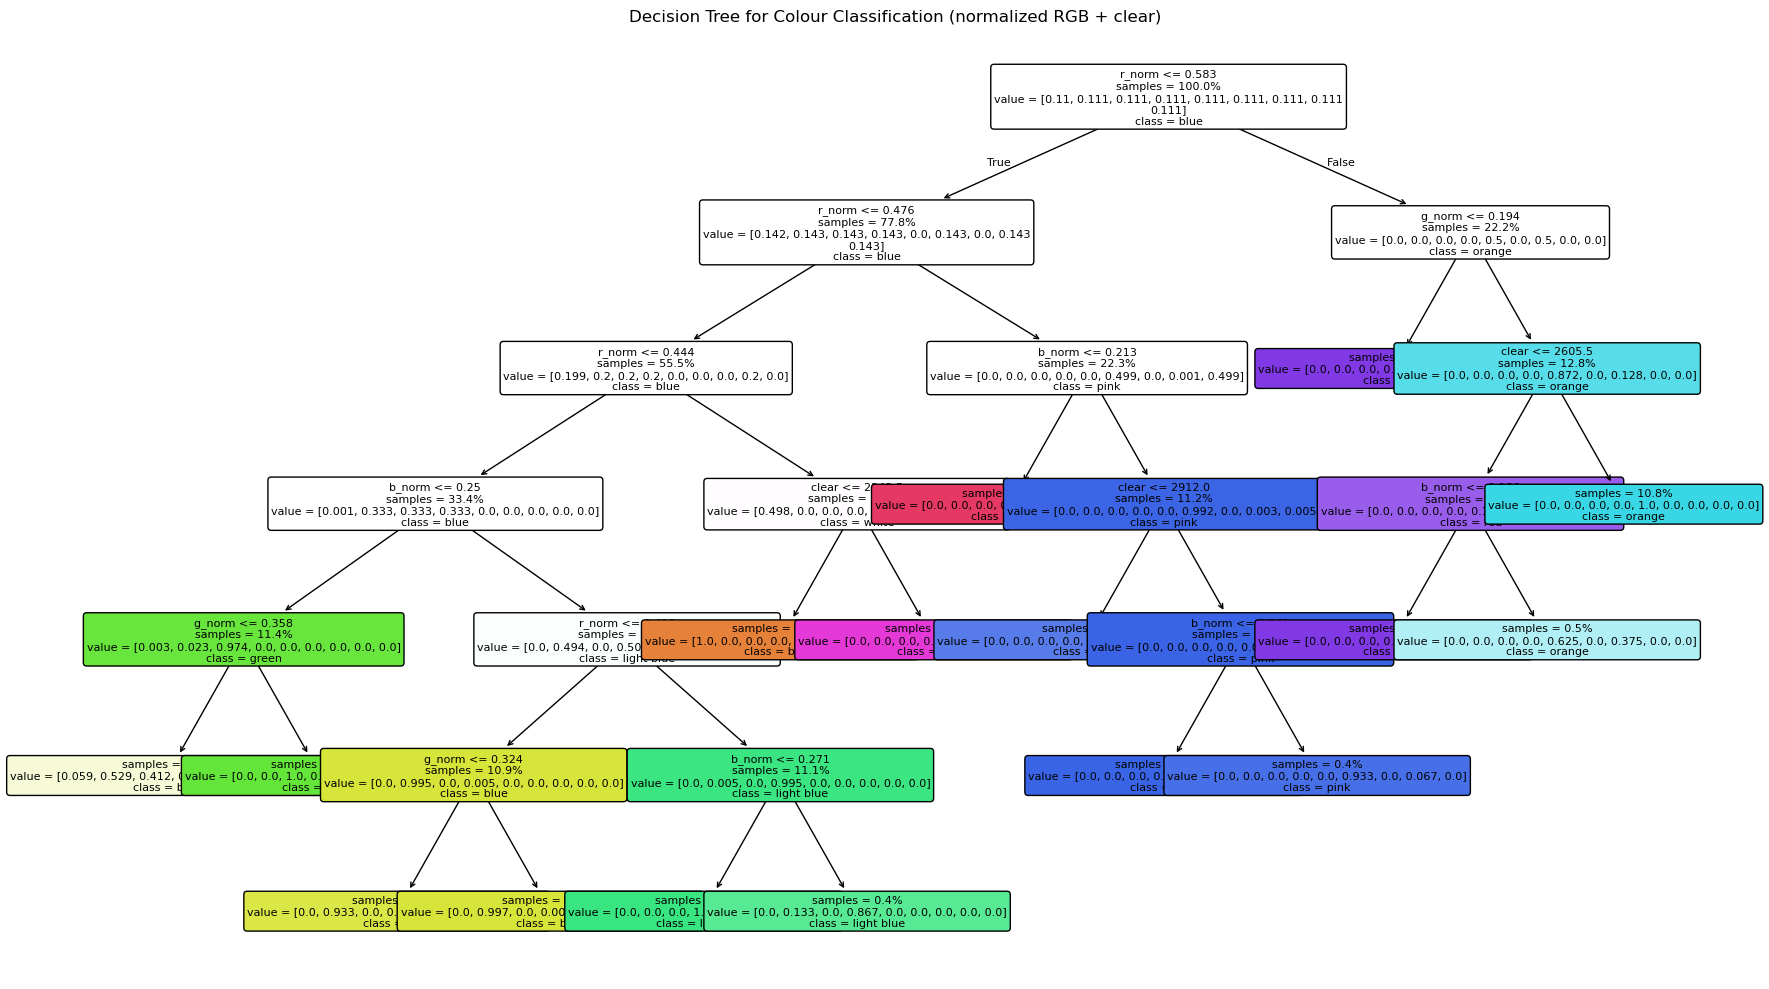

In [3]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Draw the decision tree as a diagram
plt.figure(figsize=(18, 10))
plot_tree(
    clf,
    feature_names=["r_norm", "g_norm", "b_norm", "clear"],
    class_names=clf.classes_,
    filled=True,      # Color nodes by predicted class
    rounded=True,
    impurity=False,   # Hide Gini to keep it cleaner
    proportion=True,  # Show class proportions (more informative than raw counts)
    fontsize=8
)

plt.title("Decision Tree for Colour Classification (normalized RGB + clear)")
plt.tight_layout()

# Save to a file (optional, but useful for reports)
plt.savefig("decision_tree.png", dpi=200)
plt.show()

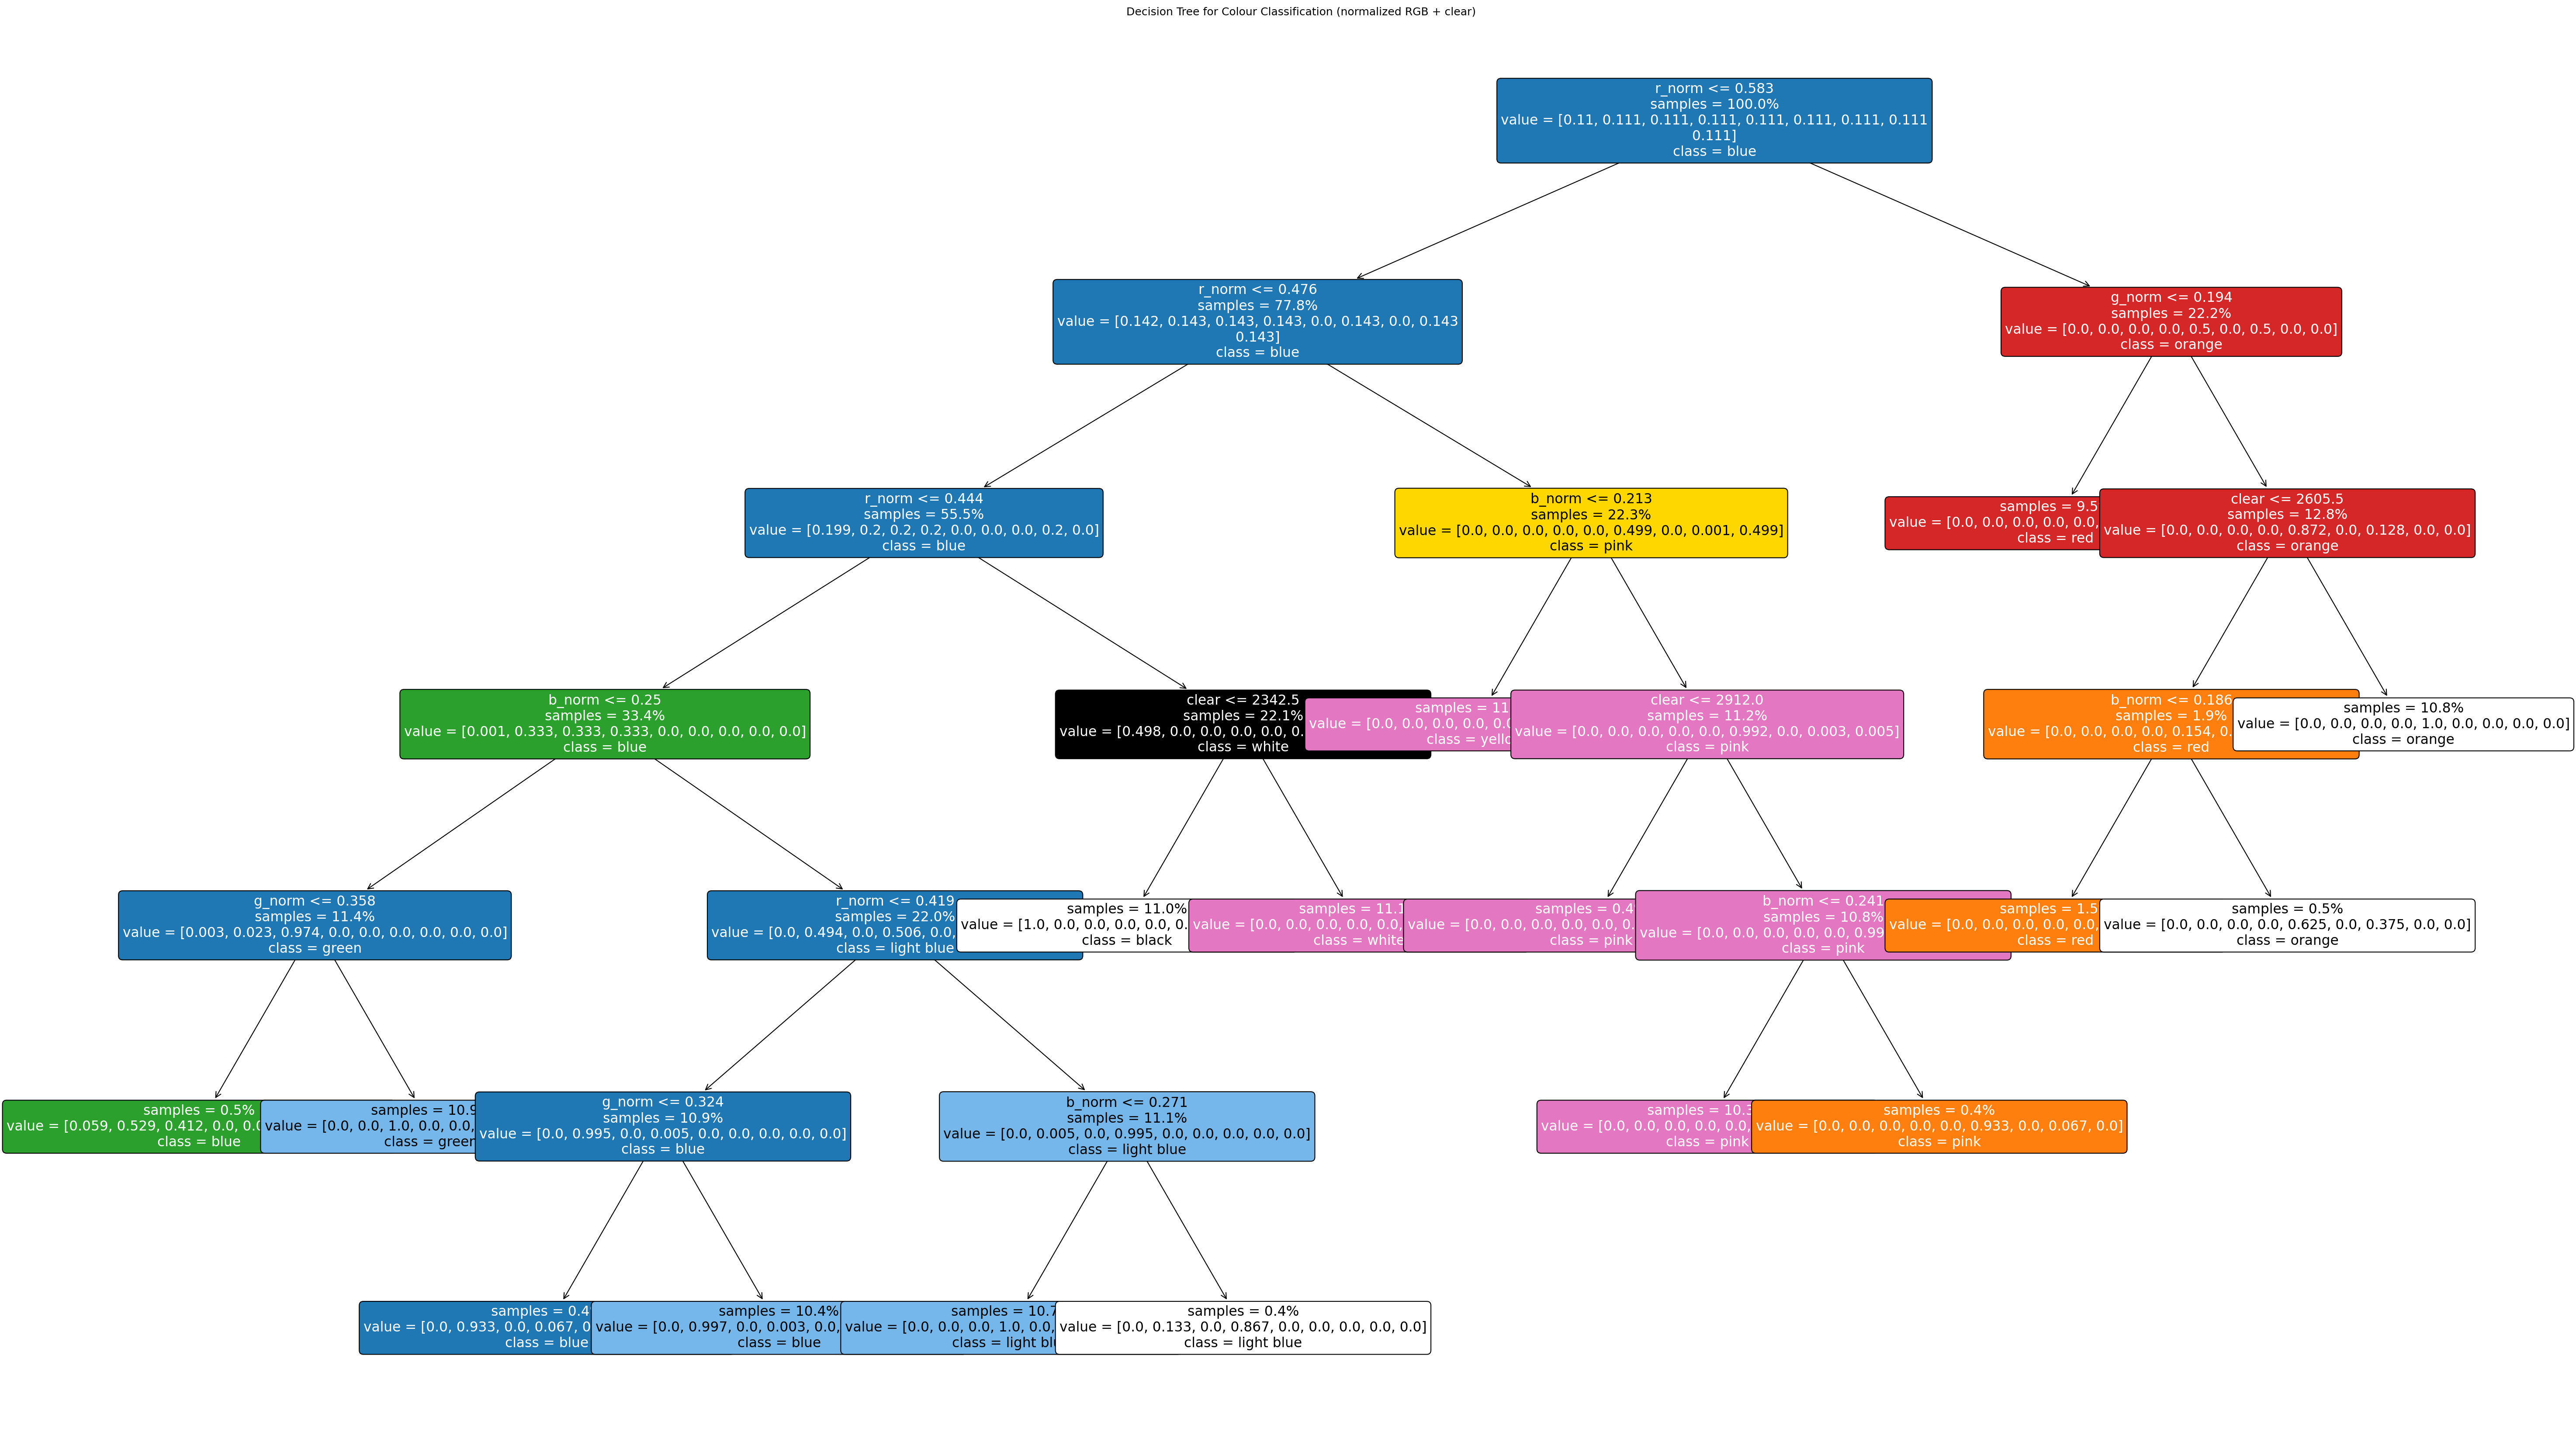

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Fixed label -> colour mapping
LABEL_TO_COLOR = {
    "black": "#000000",
    "blue": "#1f77b4",
    "green": "#2ca02c",
    "light blue": "#76b7eb",
    "orange": "#ff7f0e",
    "pink": "#e377c2",
    "red": "#d62728",
    "white": "#ffffff",
    "yellow": "#ffd700",
}

# Make the figure much larger to avoid clutter
fig, ax = plt.subplots(figsize=(40, 22), dpi=150)

# IMPORTANT: capture the returned text artists
texts = plot_tree(
    clf,
    feature_names=["r_norm", "g_norm", "b_norm", "clear"],
    class_names=clf.classes_,
    filled=False,      # we will set colors ourselves
    rounded=True,
    impurity=False,
    proportion=True,
    fontsize=15,
    ax=ax
)

tree = clf.tree_
node_count = tree.node_count

# Sometimes plot_tree returns exactly node_count texts
# If it returns more (rare), we only recolor the first node_count.
n = min(len(texts), node_count)

for node_id in range(n):
    # Predicted class at this node
    cls_id = int(np.argmax(tree.value[node_id][0]))
    label = str(clf.classes_[cls_id]).strip().lower()

    face = LABEL_TO_COLOR.get(label, "#cccccc")  # fallback gray

    t = texts[node_id]
    bbox = t.get_bbox_patch()
    if bbox is not None:
        bbox.set_facecolor(face)
        bbox.set_edgecolor("#000000")
        bbox.set_linewidth(1.0)

    # Make text readable on dark nodes
    if label in ("black", "blue", "red", "green", "orange", "pink"):
        t.set_color("white")
    else:
        t.set_color("black")

ax.set_title("Decision Tree for Colour Classification (normalized RGB + clear)")
plt.tight_layout()
plt.savefig("decision_tree.png", dpi=300, bbox_inches="tight")
plt.show()

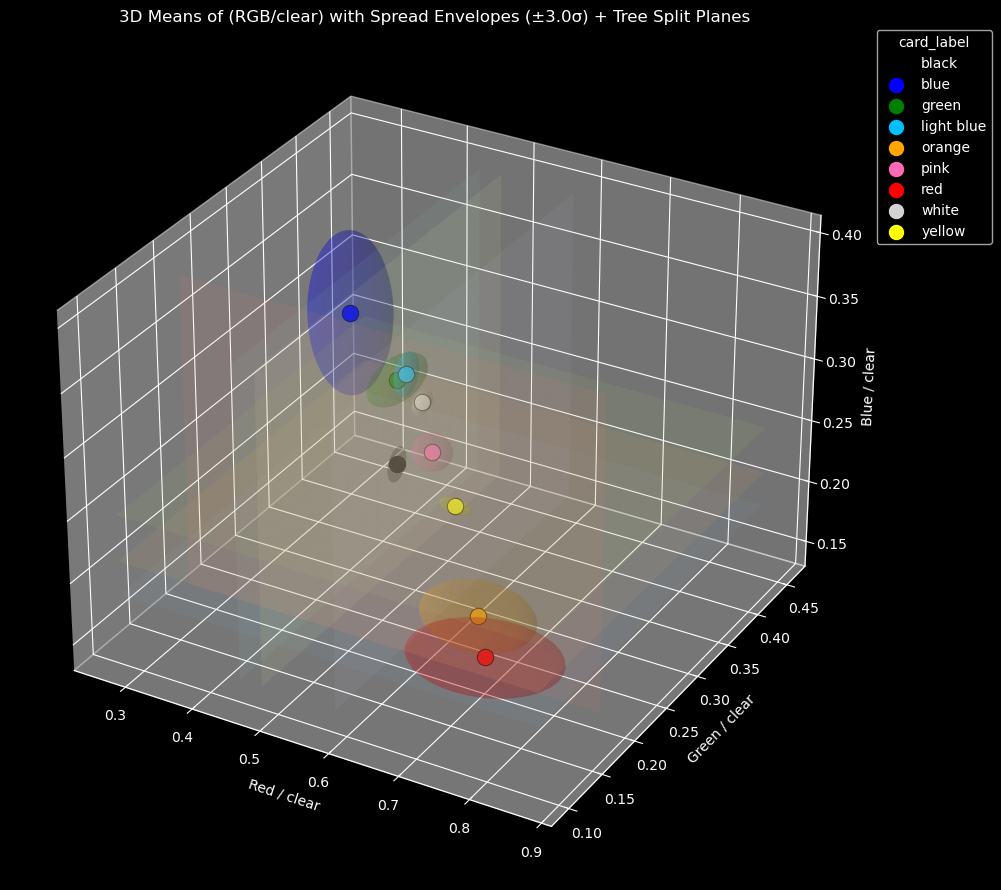

In [12]:
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Load data (mode=A) from SQLite
# -----------------------------
db_path = "color_data/color_data.db"
with sqlite3.connect(db_path) as conn:
    df = pd.read_sql_query(
        """
        SELECT timestamp, mode, card_label, clear, red, green, blue
        FROM colordata_v2
        WHERE mode = 'A'
        """,
        conn
    )

# -----------------------------
# Clean + normalize
# -----------------------------
cols = ["clear", "red", "green", "blue"]
df = df.dropna(subset=cols).copy()
for col in cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df = df.dropna(subset=cols)

min_clear = 50
df = df[df["clear"] >= min_clear].copy()

df["r_norm"] = df["red"] / df["clear"]
df["g_norm"] = df["green"] / df["clear"]
df["b_norm"] = df["blue"] / df["clear"]
df["card_label_norm"] = df["card_label"].astype(str).str.strip().str.lower()

label_to_color = {
    "black": "black",
    "blue": "blue",
    "green": "green",
    "light blue": "deepskyblue",
    "light_blue": "deepskyblue",
    "orange": "orange",
    "pink": "hotpink",
    "red": "red",
    "white": "lightgray",
    "yellow": "yellow",
}

# Mean/std in normalized space
stats = (
    df.groupby("card_label_norm")[["r_norm", "g_norm", "b_norm"]]
      .agg(["mean", "std", "count"])
)
stats.columns = ["_".join(c) for c in stats.columns]
stats = stats.reset_index()

def plot_std_ellipsoid(ax, center, radii, color, alpha=0.22, n=36):
    """Draw a 3D axis-aligned ellipsoid centered at `center` with radii `radii`."""
    u = np.linspace(0, 2*np.pi, n)
    v = np.linspace(0, np.pi, n)
    x = radii[0] * np.outer(np.cos(u), np.sin(v)) + center[0]
    y = radii[1] * np.outer(np.sin(u), np.sin(v)) + center[1]
    z = radii[2] * np.outer(np.ones_like(u), np.cos(v)) + center[2]
    ax.plot_surface(x, y, z, color=color, alpha=alpha, linewidth=0, shade=True)

def add_tree_split_planes(ax, clf, max_depth_to_show=3, alpha=0.10, n=18):
    """
    Overlay axis-aligned split planes from a DecisionTree on a 3D plot.
    Only draws splits on r_norm/g_norm/b_norm (not clear).
    """
    # Ensure this is a 3D axis (otherwise get_zlim isn't available)
    if not hasattr(ax, "get_zlim") and not hasattr(ax, "get_zlim3d"):
        raise TypeError("ax is not a 3D axis. Use: ax = fig.add_subplot(111, projection='3d')")

    def _get_zlim(a):
        return a.get_zlim3d() if hasattr(a, "get_zlim3d") else a.get_zlim()

    tree = clf.tree_
    feat = tree.feature
    thr = tree.threshold
    left = tree.children_left
    right = tree.children_right

    # Compute node depths so we can draw only top layers
    node_depth = np.zeros(tree.node_count, dtype=int)
    stack = [(0, 0)]
    while stack:
        node_id, depth = stack.pop()
        node_depth[node_id] = depth
        if left[node_id] != right[node_id]:
            stack.append((left[node_id], depth + 1))
            stack.append((right[node_id], depth + 1))

    # Axis ranges
    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()
    z0, z1 = _get_zlim(ax)

    xs = np.linspace(x0, x1, n)
    ys = np.linspace(y0, y1, n)
    zs = np.linspace(z0, z1, n)

    # Collect thresholds for r_norm(0), g_norm(1), b_norm(2)
    r_thrs, g_thrs, b_thrs = set(), set(), set()
    for i in range(tree.node_count):
        if node_depth[i] > max_depth_to_show:
            continue
        if feat[i] == 0:
            r_thrs.add(thr[i])
        elif feat[i] == 1:
            g_thrs.add(thr[i])
        elif feat[i] == 2:
            b_thrs.add(thr[i])
        # feat==3 (clear) cannot be shown in this 3D plot

    # Draw planes: x=const, y=const, z=const
    Y, Z = np.meshgrid(ys, zs)
    for t in sorted(r_thrs):
        X = np.full_like(Y, t)
        ax.plot_surface(X, Y, Z, alpha=alpha, linewidth=0, shade=False)

    X, Z = np.meshgrid(xs, zs)
    for t in sorted(g_thrs):
        Y = np.full_like(X, t)
        ax.plot_surface(X, Y, Z, alpha=alpha, linewidth=0, shade=False)

    X, Y = np.meshgrid(xs, ys)
    for t in sorted(b_thrs):
        Z = np.full_like(X, t)
        ax.plot_surface(X, Y, Z, alpha=alpha, linewidth=0, shade=False)

# -----------------------------
# 3D plot (make sure ax is truly 3D)
# -----------------------------
plt.style.use("dark_background")
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection="3d")

k_sigma = 3.0

for _, row in stats.iterrows():
    label = row["card_label_norm"]
    c = label_to_color.get(label, "gray")

    center = np.array([row["r_norm_mean"], row["g_norm_mean"], row["b_norm_mean"]], dtype=float)
    radii  = np.array([row["r_norm_std"],  row["g_norm_std"],  row["b_norm_std"]], dtype=float) * k_sigma

    ax.scatter(center[0], center[1], center[2],
               s=140, c=c, edgecolors="k", linewidths=0.7, label=label)

    if np.all(np.isfinite(radii)) and np.all(radii > 0):
        plot_std_ellipsoid(ax, center, radii, c, alpha=0.20, n=34)

ax.set_title(f"3D Means of (RGB/clear) with Spread Envelopes (±{k_sigma:.1f}σ) + Tree Split Planes")
ax.set_xlabel("Red / clear")
ax.set_ylabel("Green / clear")
ax.set_zlabel("Blue / clear")
ax.grid(True, linewidth=0.4, alpha=0.25)

# -----------------------------
# Overlay tree split planes (needs clf already trained)
# -----------------------------
# NOTE: clf must exist in your notebook before this cell runs.
# Reduce max_depth_to_show if it looks too cluttered.
add_tree_split_planes(ax, clf, max_depth_to_show=3, alpha=0.08, n=18)

ax.legend(title="card_label", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.show()

Evaluate the trained decision tree classifier on the full dataset and report

per-class accuracy (correct predictions / total samples for each colour).
                    
This helps identify which colours are reliably recognised and which ones
    
need more data, better features, or different thresholds.


In [13]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score

# --- 1) Prepare features from the raw dataset (same preprocessing as training) ---
cols = ["clear", "red", "green", "blue", "card_label"]
d = df.dropna(subset=cols).copy()
for c in ["clear", "red", "green", "blue"]:
    d[c] = pd.to_numeric(d[c], errors="coerce")
d = d.dropna(subset=["clear", "red", "green", "blue"])
d = d[d["clear"] > 0].copy()

# If you used a clear threshold for training, apply the same here:
MIN_CLEAR = 80
d = d[d["clear"] >= MIN_CLEAR].copy()

# Features must match training: r_norm, g_norm, b_norm, clear
d["r_norm"] = d["red"] / d["clear"]
d["g_norm"] = d["green"] / d["clear"]
d["b_norm"] = d["blue"] / d["clear"]
d["label"] = d["card_label"].astype(str).str.strip().str.lower()

X_all = d[["r_norm", "g_norm", "b_norm", "clear"]].to_numpy()
y_true = d["label"].to_numpy()

# --- 2) Predict with the trained tree ---
y_pred = clf.predict(X_all)

# --- 3) Per-class accuracy (correct / total) ---
results = (
    pd.DataFrame({"label": y_true, "pred": y_pred})
      .assign(correct=lambda t: (t["label"] == t["pred"]).astype(int))
      .groupby("label")
      .agg(total=("correct", "size"), correct=("correct", "sum"))
      .assign(accuracy=lambda t: t["correct"] / t["total"])
      .sort_values("accuracy", ascending=False)
)

display(results)

# Optional: overall accuracy (not per-class)
print("Overall accuracy:", accuracy_score(y_true, y_pred))

,total,correct,accuracy
label,,,
orange,500,500,1.000000
pink,500,499,0.998000
white,500,499,0.998000
black,497,496,0.997988
blue,500,498,0.996000
light blue,500,498,0.996000
yellow,500,498,0.996000
green,500,493,0.986000
red,500,493,0.986000


Overall accuracy: 0.9948854792083611


In [15]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score

# Purpose:
# Evaluate the trained decision tree on the dataset and report per-class accuracy.
# In addition to accuracy, we also show which wrong labels each class is confused with.

# --- 1) Prepare features from the raw dataset ---
cols = ["clear", "red", "green", "blue", "card_label"]
d = df.dropna(subset=cols).copy()
for c in ["clear", "red", "green", "blue"]:
    d[c] = pd.to_numeric(d[c], errors="coerce")
d = d.dropna(subset=["clear", "red", "green", "blue"])
d = d[d["clear"] > 0].copy()

MIN_CLEAR_TEST = 20
d = d[d["clear"] >= MIN_CLEAR_TEST].copy()

# Features must match training
d["r_norm"] = d["red"] / d["clear"]
d["g_norm"] = d["green"] / d["clear"]
d["b_norm"] = d["blue"] / d["clear"]
d["label"] = d["card_label"].astype(str).str.strip().str.lower()

print("Samples per label in evaluation set:")
print(d["label"].value_counts())

X_all = d[["r_norm", "g_norm", "b_norm", "clear"]].to_numpy()
y_true = d["label"].to_numpy()

# --- 2) Predict with the trained tree ---
y_pred = clf.predict(X_all)

# Helper: for each true label, summarize the wrong predictions (counts)
pred_series = pd.Series(y_pred, index=d.index, name="pred")
true_series = pd.Series(y_true, index=d.index, name="label")

def misclass_summary(group_df):
    # group_df has columns: label, pred
    wrong = group_df[group_df["label"] != group_df["pred"]]
    if wrong.empty:
        return ""
    counts = wrong["pred"].value_counts()
    # format like: "green:12, light blue:3"
    return ", ".join([f"{k}:{v}" for k, v in counts.items()])

# --- 3) Per-class accuracy + misclassification column ---
eval_df = pd.DataFrame({"label": true_series, "pred": pred_series})
results = (
    eval_df.assign(correct=(eval_df["label"] == eval_df["pred"]).astype(int))
           .groupby("label")
           .agg(
               total=("correct", "size"),
               correct=("correct", "sum"),
               misclassified_as=("pred", lambda s: misclass_summary(eval_df.loc[s.index]))
           )
           .assign(accuracy=lambda t: t["correct"] / t["total"])
           .sort_values("accuracy", ascending=False)
)

display(results)
print("Overall accuracy:", accuracy_score(y_true, y_pred))

Samples per label in evaluation set:
label
red           500
green         500
blue          500
yellow        500
orange        500
light blue    500
white         500
pink          500
black         497
Name: count, dtype: int64


,total,correct,misclassified_as,accuracy
label,,,,
orange,500,500,,1.000000
pink,500,499,orange:1,0.998000
white,500,499,pink:1,0.998000
black,497,496,blue:1,0.997988
blue,500,498,light blue:2,0.996000
light blue,500,498,blue:2,0.996000
yellow,500,498,pink:2,0.996000
green,500,493,blue:7,0.986000
red,500,493,orange:7,0.986000


Overall accuracy: 0.9948854792083611


In [16]:
# Purpose:
# Improve a trained decision tree classifier by adding a second-stage correction.
# We compute a Mahalanobis-like (diagonal covariance) distance to each class centroid
# in normalized RGB space, and override the tree prediction only when the centroid-based
# prediction is significantly more plausible (distance advantage > margin). This reduces
# boundary confusions (e.g., red vs orange, blue vs light blue) without introducing NO_CARD.

import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score

# -----------------------------
# 1) Prepare evaluation set (keep black by using low clear threshold)
# -----------------------------
cols = ["clear", "red", "green", "blue", "card_label"]
d = df.dropna(subset=cols).copy()
for c in ["clear", "red", "green", "blue"]:
    d[c] = pd.to_numeric(d[c], errors="coerce")
d = d.dropna(subset=["clear", "red", "green", "blue"])
d = d[d["clear"] > 0].copy()

MIN_CLEAR_TEST = 20
d = d[d["clear"] >= MIN_CLEAR_TEST].copy()

d["r_norm"] = d["red"] / d["clear"]
d["g_norm"] = d["green"] / d["clear"]
d["b_norm"] = d["blue"] / d["clear"]
d["label"] = d["card_label"].astype(str).str.strip().str.lower()

X_all = d[["r_norm", "g_norm", "b_norm", "clear"]].to_numpy()
X_rgb = d[["r_norm", "g_norm", "b_norm"]].to_numpy()   # used for distance correction
y_true = d["label"].to_numpy()

print("Samples per label in evaluation set:")
print(d["label"].value_counts())

# -----------------------------
# 2) Tree prediction (baseline)
# -----------------------------
y_tree = clf.predict(X_all)

# -----------------------------
# 3) Mahalanobis-like nearest-centroid prediction (diagonal covariance)
#    IMPORTANT: compute stats from a "reference set".
#    If you have X_train/y_train from earlier, use them here instead of all data.
# -----------------------------
# If you still have training split, use that:
#   ref_df = pd.DataFrame({"label": y_train})
#   ref_rgb = X_train[:, :3]   # r_norm,g_norm,b_norm
# Otherwise, fall back to using the evaluation set itself (optimistic but ok for quick tuning):
ref_df = d[["label"]].copy()
ref_rgb = X_rgb.copy()

labels = sorted(ref_df["label"].unique())
label_to_idx = {lab: i for i, lab in enumerate(labels)}

# Compute per-class mean and std (std floor prevents divide-by-zero)
STD_FLOOR = 1e-6
means = np.zeros((len(labels), 3), dtype=float)
stds  = np.zeros((len(labels), 3), dtype=float)

for lab in labels:
    idx = (ref_df["label"].to_numpy() == lab)
    m = ref_rgb[idx].mean(axis=0)
    s = ref_rgb[idx].std(axis=0)
    means[label_to_idx[lab]] = m
    stds[label_to_idx[lab]]  = np.maximum(s, STD_FLOOR)

def maha_diag_dist(x_rgb, means, stds):
    """
    Diagonal Mahalanobis-like distance (no sqrt):
      D = sum(((x - mu)/sigma)^2)  over RGB-normalized dimensions
    Returns: (N, K) distances
    """
    z = (x_rgb[:, None, :] - means[None, :, :]) / stds[None, :, :]
    return np.sum(z * z, axis=2)

D = maha_diag_dist(X_rgb, means, stds)                 # shape (N, K)
maha_idx = np.argmin(D, axis=1)
y_maha = np.array([labels[i] for i in maha_idx])

# Distance of the tree-chosen class vs the best (maha) class
# (If tree predicts a label not in labels, handle safely)
tree_idx = np.array([label_to_idx.get(lab, -1) for lab in y_tree])
D_tree = np.full(len(d), np.inf, dtype=float)
valid = tree_idx >= 0
D_tree[valid] = D[np.arange(len(d))[valid], tree_idx[valid]]
D_best = D[np.arange(len(d)), maha_idx]

# -----------------------------
# 4) Hybrid rule: override only when maha is clearly better
# -----------------------------
# We will tune a small list of margins and pick the best one on THIS evaluation set.
# If you want proper tuning, tune on a validation split, not on the final test.
MARGINS = [0.0, 0.5, 1.0, 2.0, 3.0]  # larger => fewer overrides

best_margin = None
best_acc = -1.0
best_pred = None

for margin in MARGINS:
    y_hybrid = y_tree.copy()
    override = (y_maha != y_tree) & ((D_tree - D_best) > margin)
    y_hybrid[override] = y_maha[override]

    acc = accuracy_score(y_true, y_hybrid)
    if acc > best_acc:
        best_acc = acc
        best_margin = margin
        best_pred = y_hybrid

print(f"\nBest margin = {best_margin}  |  Overall accuracy = {best_acc:.6f}")

# -----------------------------
# 5) Per-class accuracy + misclassified_as (for the best hybrid)
# -----------------------------
eval_df = pd.DataFrame({"label": y_true, "pred": best_pred})
results = (
    eval_df.assign(correct=(eval_df["label"] == eval_df["pred"]).astype(int))
           .groupby("label")
           .agg(
               total=("correct", "size"),
               correct=("correct", "sum"),
               misclassified_as=("pred", lambda s: ", ".join(
                   f"{k}:{v}" for k, v in eval_df.loc[s.index].query("label != pred")["pred"].value_counts().items()
               ))
           )
           .assign(accuracy=lambda t: t["correct"] / t["total"])
           .sort_values("accuracy", ascending=False)
)

display(results)

Samples per label in evaluation set:
label
red           500
green         500
blue          500
yellow        500
orange        500
light blue    500
white         500
pink          500
black         497
Name: count, dtype: int64

Best margin = 3.0  |  Overall accuracy = 0.980431


,total,correct,misclassified_as,accuracy
label,,,,
blue,500,500,,1.000000
orange,500,499,blue:1,0.998000
light blue,500,498,blue:2,0.996000
pink,500,498,blue:2,0.996000
white,500,498,"blue:1, black:1",0.996000
yellow,500,498,pink:2,0.996000
black,497,495,blue:2,0.995976
green,500,493,blue:7,0.986000
red,500,430,orange:70,0.860000


In [17]:
# Purpose:
# Improve colour classification accuracy by training a decision tree ONLY on chromaticity
# features (r_norm, g_norm, b_norm). We explicitly remove "clear" from the classifier so the
# model does not learn brightness/distance splits that can harm colour separation. We then
# search a small set of tree hyperparameters and report per-class accuracy and confusions.

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# --- 1) Build dataset (keep black by using a low clear threshold) ---
cols = ["clear", "red", "green", "blue", "card_label"]
d = df.dropna(subset=cols).copy()
for c in ["clear", "red", "green", "blue"]:
    d[c] = pd.to_numeric(d[c], errors="coerce")
d = d.dropna(subset=["clear", "red", "green", "blue"])
d = d[d["clear"] > 0].copy()

MIN_CLEAR_DATASET = 20
d = d[d["clear"] >= MIN_CLEAR_DATASET].copy()

d["r_norm"] = d["red"] / d["clear"]
d["g_norm"] = d["green"] / d["clear"]
d["b_norm"] = d["blue"] / d["clear"]
d["label"] = d["card_label"].astype(str).str.strip().str.lower()

X = d[["r_norm", "g_norm", "b_norm"]].to_numpy()   # <-- no "clear" here
y = d["label"].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# --- 2) Small hyperparameter search (fast) ---
candidates = []
for depth in [3, 4, 5, 6, 7, 8]:
    for leaf in [3, 5, 10, 15, 25]:
        clf2 = DecisionTreeClassifier(
            max_depth=depth,
            min_samples_leaf=leaf,
            random_state=42,
            class_weight="balanced"   # helps minority-like patterns (often useful for black)
        )
        clf2.fit(X_train, y_train)
        pred = clf2.predict(X_test)
        acc = accuracy_score(y_test, pred)
        candidates.append((acc, depth, leaf, clf2))

candidates.sort(reverse=True, key=lambda t: t[0])
best_acc, best_depth, best_leaf, best_clf = candidates[0]
print(f"Best tree (no clear): acc={best_acc:.6f}, max_depth={best_depth}, min_samples_leaf={best_leaf}")

# --- 3) Per-class accuracy + misclassified_as on TEST set ---
pred = best_clf.predict(X_test)
eval_df = pd.DataFrame({"label": y_test, "pred": pred})
results = (
    eval_df.assign(correct=(eval_df["label"] == eval_df["pred"]).astype(int))
           .groupby("label")
           .agg(
               total=("correct", "size"),
               correct=("correct", "sum"),
               misclassified_as=("pred", lambda s: ", ".join(
                   f"{k}:{v}" for k, v in eval_df.loc[s.index].query("label != pred")["pred"].value_counts().items()
               ))
           )
           .assign(accuracy=lambda t: t["correct"] / t["total"])
           .sort_values("accuracy", ascending=False)
)

display(results)
print("Overall test accuracy:", accuracy_score(y_test, pred))

Best tree (no clear): acc=1.000000, max_depth=6, min_samples_leaf=3


,total,correct,misclassified_as,accuracy
label,,,,
black,125,125,,1.0
blue,125,125,,1.0
green,125,125,,1.0
light blue,125,125,,1.0
orange,125,125,,1.0
pink,125,125,,1.0
red,125,125,,1.0
white,125,125,,1.0
yellow,125,125,,1.0


Overall test accuracy: 1.0


In [20]:
# Purpose:
# Train a colour classifier using the newer "colordata_v2" table, then test it on the older
# "color_data" table (different schema). We only SELECT the columns we actually need,
# compute brightness-normalised chromaticity features (R/C, G/C, B/C), and report per-class
# accuracy on the held-out table to check cross-dataset generalisation.

import sqlite3
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

db_path = "color_data/color_data.db"

def load_v2(mode="A") -> pd.DataFrame:
    with sqlite3.connect(db_path) as conn:
        df = pd.read_sql_query(
            """
            SELECT clear, red, green, blue, card_label
            FROM colordata_v2
            WHERE mode = ?
            """,
            conn,
            params=(mode,),
        )
    return df

def load_v1(mode="A") -> pd.DataFrame:
    with sqlite3.connect(db_path) as conn:
        df = pd.read_sql_query(
            """
            SELECT clear, red, green, blue, card_label
            FROM color_data
            WHERE mode = ?
            """,
            conn,
            params=(mode,),
        )
    return df

def preprocess(df: pd.DataFrame, min_clear: int = 20) -> pd.DataFrame:
    # Ensure numeric + drop invalid rows
    cols = ["clear", "red", "green", "blue"]
    df = df.dropna(subset=cols + ["card_label"]).copy()
    for c in cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.dropna(subset=cols)
    df = df[df["clear"] > 0].copy()
    df = df[df["clear"] >= min_clear].copy()

    # Chromaticity features (brightness-invariant)
    df["r_norm"] = df["red"] / df["clear"]
    df["g_norm"] = df["green"] / df["clear"]
    df["b_norm"] = df["blue"] / df["clear"]

    # Normalised labels
    df["label"] = df["card_label"].astype(str).str.strip().str.lower()
    return df

# ---- 1) Load + preprocess ----
MIN_CLEAR_TRAIN = 20
MIN_CLEAR_TEST  = 20

train_df = preprocess(load_v2(mode="A"), min_clear=MIN_CLEAR_TRAIN)  # v2 table
test_df  = preprocess(load_v1(mode="A"), min_clear=MIN_CLEAR_TEST)   # v1 table

print("Train label counts (colordata_v2):")
print(train_df["label"].value_counts())
print("\nTest label counts (color_data):")
print(test_df["label"].value_counts())

# ---- 2) Train on v2 (NO 'clear' as a feature) ----
X_train = train_df[["r_norm", "g_norm", "b_norm"]].to_numpy()
y_train = train_df["label"].to_numpy()

clf = DecisionTreeClassifier(
    max_depth=6,
    min_samples_leaf=15,
    random_state=42,
    class_weight="balanced"
)
clf.fit(X_train, y_train)

# ---- 3) Test on v1 ----
X_test = test_df[["r_norm", "g_norm", "b_norm"]].to_numpy()
y_true = test_df["label"].to_numpy()
y_pred = clf.predict(X_test)

# ---- 4) Per-class accuracy ----
eval_df = pd.DataFrame({"label": y_true, "pred": y_pred})
results = (
    eval_df.assign(correct=(eval_df["label"] == eval_df["pred"]).astype(int))
           .groupby("label")
           .agg(total=("correct", "size"), correct=("correct", "sum"))
           .assign(accuracy=lambda t: t["correct"] / t["total"])
           .sort_values("accuracy", ascending=False)
)

display(results)
print("Overall test accuracy (color_data):", accuracy_score(y_true, y_pred))

Train label counts (colordata_v2):
label
red           500
green         500
blue          500
yellow        500
orange        500
light blue    500
white         500
black         500
pink          500
Name: count, dtype: int64

Test label counts (color_data):
label
green         1000
orange        1000
pink          1000
red           1000
yellow         999
black          998
light blue     998
blue           997
white          997
Name: count, dtype: int64


,total,correct,accuracy
label,,,
black,998,998,1.000000
blue,997,989,0.991976
yellow,999,976,0.976977
orange,1000,500,0.500000
pink,1000,500,0.500000
light blue,998,498,0.498998
white,997,497,0.498495
red,1000,498,0.498000
green,1000,496,0.496000


Overall test accuracy (color_data): 0.6621426187562577


### Mixed V1+V2 training with a 25% held-out test set

In this experiment, I merged two SQLite tables that store colour sensor readings: the original `color_data` (V1) and the newer `colordata_v2` (V2). Even though the schemas are different, both tables contain the same essential measurements (clear, red, green, blue) and a colour label. I only selected those common columns and ignored metadata fields that are not needed for classification.

To make the classifier less sensitive to distance and illumination, I converted the raw readings into chromaticity features by normalising each colour channel by the clear channel:  
\( r = R/C,\; g = G/C,\; b = B/C \).  
These ratios represent colour proportions and are more stable under brightness changes than raw RGB values.

I then concatenated the preprocessed V1 and V2 samples into a single dataset and performed a stratified train/test split, reserving 25% of the data for testing. Stratification ensures each colour appears in both sets with similar proportions. A decision tree classifier (using only \((r,g,b)\)) was trained on the remaining 75% and evaluated on the held-out 25%. Results are reported as overall accuracy and per-class accuracy, with an additional summary of common misclassifications for each colour.

In [21]:
import sqlite3
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

db_path = "color_data/color_data.db"

def load_v1(mode="A") -> pd.DataFrame:
    # V1 schema has extra columns (distance_mm, timestamp as TEXT), we only select what we need.
    with sqlite3.connect(db_path) as conn:
        return pd.read_sql_query(
            """
            SELECT clear, red, green, blue, card_label
            FROM color_data
            WHERE mode = ?
            """,
            conn,
            params=(mode,),
        )

def load_v2(mode="A") -> pd.DataFrame:
    # V2 schema has id/timestamp REAL; again only select what we need.
    with sqlite3.connect(db_path) as conn:
        return pd.read_sql_query(
            """
            SELECT clear, red, green, blue, card_label
            FROM colordata_v2
            WHERE mode = ?
            """,
            conn,
            params=(mode,),
        )

def preprocess(df: pd.DataFrame, min_clear: int = 20) -> pd.DataFrame:
    cols = ["clear", "red", "green", "blue"]
    df = df.dropna(subset=cols + ["card_label"]).copy()
    for c in cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.dropna(subset=cols)

    # Basic validity checks
    df = df[df["clear"] > 0].copy()
    df = df[df["clear"] >= min_clear].copy()

    # Brightness-invariant chromaticity features
    df["r_norm"] = df["red"] / df["clear"]
    df["g_norm"] = df["green"] / df["clear"]
    df["b_norm"] = df["blue"] / df["clear"]

    # Normalise labels
    df["label"] = df["card_label"].astype(str).str.strip().str.lower()
    return df

# -----------------------------
# 1) Load + merge V1 and V2
# -----------------------------
MIN_CLEAR_DATASET = 20  # keep black; adjust if you want to exclude very dark noise

v1 = preprocess(load_v1(mode="A"), min_clear=MIN_CLEAR_DATASET)
v2 = preprocess(load_v2(mode="A"), min_clear=MIN_CLEAR_DATASET)

# Add a source tag (useful for debugging generalisation)
v1["source"] = "v1"
v2["source"] = "v2"

all_df = pd.concat([v1, v2], ignore_index=True)

print("Merged label counts:")
print(all_df["label"].value_counts())
print("\nMerged source counts:")
print(all_df["source"].value_counts())

# -----------------------------
# 2) Train/test split (25% test)
# -----------------------------
X = all_df[["r_norm", "g_norm", "b_norm"]].to_numpy()   # classifier uses chromaticity only
y = all_df["label"].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# -----------------------------
# 3) Train model
# -----------------------------
clf = DecisionTreeClassifier(
    max_depth=6,
    min_samples_leaf=15,
    random_state=42,
    class_weight="balanced"
)
clf.fit(X_train, y_train)

# -----------------------------
# 4) Evaluate (per-class + confusion summary)
# -----------------------------
y_pred = clf.predict(X_test)
print("\nOverall test accuracy:", accuracy_score(y_test, y_pred))

eval_df = pd.DataFrame({"label": y_test, "pred": y_pred})
def misclass_summary(group: pd.DataFrame) -> str:
    wrong = group[group["label"] != group["pred"]]
    if wrong.empty:
        return ""
    vc = wrong["pred"].value_counts()
    return ", ".join([f"{k}:{v}" for k, v in vc.items()])

results = (
    eval_df.assign(correct=(eval_df["label"] == eval_df["pred"]).astype(int))
           .groupby("label")
           .agg(
               total=("correct", "size"),
               correct=("correct", "sum"),
               accuracy=("correct", "mean"),
               misclassified_as=("pred", lambda s: misclass_summary(eval_df.loc[s.index])),
           )
           .sort_values("accuracy", ascending=False)
)

display(results)

Merged label counts:
label
green         1500
orange        1500
pink          1500
red           1500
yellow        1499
black         1498
light blue    1498
blue          1497
white         1497
Name: count, dtype: int64

Merged source counts:
source
v1    8989
v2    4500
Name: count, dtype: int64

Overall test accuracy: 0.9928846723984583


,total,correct,accuracy,misclassified_as
label,,,,
orange,375,375,1.000000,
yellow,375,375,1.000000,
white,374,373,0.997326,light blue:1
pink,375,373,0.994667,"white:1, light blue:1"
red,375,372,0.992000,"orange:2, white:1"
blue,374,371,0.991979,"light blue:2, green:1"
black,375,371,0.989333,"white:2, green:2"
light blue,375,370,0.986667,blue:5
green,375,369,0.984000,"black:5, blue:1"


Train and evaluate a Random Forest classifier on the merged V1+V2 dataset.

In [22]:
# Purpose:
# Train and evaluate a Random Forest classifier on the merged V1+V2 dataset.
# Random Forests combine many decision trees and vote on the final class, which
# typically reduces boundary/threshold errors compared to a single tree (e.g.,
# blue vs light blue, green vs black). We report overall accuracy plus per-class
# accuracy and a summary of common misclassifications.

import sqlite3
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

db_path = "color_data/color_data.db"

def load_table(table_name: str, mode: str = "A") -> pd.DataFrame:
    # Only load the columns needed for classification (schema differs between tables)
    with sqlite3.connect(db_path) as conn:
        df = pd.read_sql_query(
            f"""
            SELECT clear, red, green, blue, card_label
            FROM {table_name}
            WHERE mode = ?
            """,
            conn,
            params=(mode,),
        )
    return df

def preprocess(df: pd.DataFrame, min_clear: int = 20) -> pd.DataFrame:
    # Clean numeric columns and build chromaticity features
    cols = ["clear", "red", "green", "blue"]
    df = df.dropna(subset=cols + ["card_label"]).copy()
    for c in cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.dropna(subset=cols)

    df = df[df["clear"] > 0].copy()
    df = df[df["clear"] >= min_clear].copy()

    # Brightness-invariant features
    df["r_norm"] = df["red"] / df["clear"]
    df["g_norm"] = df["green"] / df["clear"]
    df["b_norm"] = df["blue"] / df["clear"]

    df["label"] = df["card_label"].astype(str).str.strip().str.lower()
    return df

# -----------------------------
# 1) Load + merge V1 and V2
# -----------------------------
MIN_CLEAR_DATASET = 20  # keep darker samples so black remains included

v1 = preprocess(load_table("color_data", mode="A"), min_clear=MIN_CLEAR_DATASET)
v2 = preprocess(load_table("colordata_v2", mode="A"), min_clear=MIN_CLEAR_DATASET)

v1["source"] = "v1"
v2["source"] = "v2"
all_df = pd.concat([v1, v2], ignore_index=True)

print("Merged label counts:")
print(all_df["label"].value_counts())
print("\nMerged source counts:")
print(all_df["source"].value_counts())

# -----------------------------
# 2) Train/test split (25% test)
# -----------------------------
X = all_df[["r_norm", "g_norm", "b_norm"]].to_numpy()
y = all_df["label"].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# -----------------------------
# 3) Train Random Forest
# -----------------------------
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# -----------------------------
# 4) Evaluate (overall + per-class + misclassified_as)
# -----------------------------
y_pred = rf.predict(X_test)
print("\nOverall test accuracy:", accuracy_score(y_test, y_pred))

eval_df = pd.DataFrame({"label": y_test, "pred": y_pred})

def misclass_summary(group: pd.DataFrame) -> str:
    wrong = group[group["label"] != group["pred"]]
    if wrong.empty:
        return ""
    vc = wrong["pred"].value_counts()
    return ", ".join([f"{k}:{v}" for k, v in vc.items()])

results = (
    eval_df.assign(correct=(eval_df["label"] == eval_df["pred"]).astype(int))
           .groupby("label")
           .agg(
               total=("correct", "size"),
               correct=("correct", "sum"),
               accuracy=("correct", "mean"),
               misclassified_as=("pred", lambda s: misclass_summary(eval_df.loc[s.index])),
           )
           .sort_values("accuracy", ascending=False)
)

display(results)

Merged label counts:
label
green         1500
orange        1500
pink          1500
red           1500
yellow        1499
black         1498
light blue    1498
blue          1497
white         1497
Name: count, dtype: int64

Merged source counts:
source
v1    8989
v2    4500
Name: count, dtype: int64

Overall test accuracy: 0.9970352801660243


,total,correct,accuracy,misclassified_as
label,,,,
blue,374,374,1.000000,
green,375,375,1.000000,
orange,375,375,1.000000,
white,374,374,1.000000,
yellow,375,375,1.000000,
black,375,373,0.994667,green:2
pink,375,373,0.994667,white:2
light blue,375,372,0.992000,blue:3
red,375,372,0.992000,"orange:2, pink:1"


In [23]:
import sqlite3
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

db_path = "color_data/color_data.db"

def load_table(table_name: str, mode: str = "A") -> pd.DataFrame:
    with sqlite3.connect(db_path) as conn:
        return pd.read_sql_query(
            f"""
            SELECT clear, red, green, blue, card_label
            FROM {table_name}
            WHERE mode = ?
            """,
            conn,
            params=(mode,),
        )

def preprocess(df: pd.DataFrame, min_clear: int = 20) -> pd.DataFrame:
    cols = ["clear", "red", "green", "blue"]
    df = df.dropna(subset=cols + ["card_label"]).copy()
    for c in cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.dropna(subset=cols)

    df = df[df["clear"] > 0].copy()
    df = df[df["clear"] >= min_clear].copy()

    # Chromaticity features
    df["r_norm"] = df["red"] / df["clear"]
    df["g_norm"] = df["green"] / df["clear"]
    df["b_norm"] = df["blue"] / df["clear"]

    # Extra discriminative features (still stable)
    df["sum_rgb_norm"] = (df["red"] + df["green"] + df["blue"]) / df["clear"]
    df["rg"] = df["r_norm"] - df["g_norm"]
    df["bg"] = df["b_norm"] - df["g_norm"]

    df["label"] = df["card_label"].astype(str).str.strip().str.lower()
    return df

MIN_CLEAR_DATASET = 20
v1 = preprocess(load_table("color_data", mode="A"), min_clear=MIN_CLEAR_DATASET)
v2 = preprocess(load_table("colordata_v2", mode="A"), min_clear=MIN_CLEAR_DATASET)
all_df = pd.concat([v1.assign(source="v1"), v2.assign(source="v2")], ignore_index=True)

print("Merged label counts:")
print(all_df["label"].value_counts())

# Feature set (expanded)
FEATURES = ["r_norm", "g_norm", "b_norm", "sum_rgb_norm", "rg", "bg"]
X = all_df[FEATURES].to_numpy()
y = all_df["label"].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

rf = RandomForestClassifier(
    n_estimators=600,            # more trees to stabilise rare boundary cases
    max_depth=None,
    min_samples_leaf=1,          # allow finer leaves (since you have lots of data)
    min_samples_split=2,
    max_features="sqrt",         # standard RF choice
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print("\nOverall test accuracy:", accuracy_score(y_test, y_pred))

eval_df = pd.DataFrame({"label": y_test, "pred": y_pred})
def misclass_summary(group: pd.DataFrame) -> str:
    wrong = group[group["label"] != group["pred"]]
    if wrong.empty:
        return ""
    vc = wrong["pred"].value_counts()
    return ", ".join([f"{k}:{v}" for k, v in vc.items()])

results = (
    eval_df.assign(correct=(eval_df["label"] == eval_df["pred"]).astype(int))
           .groupby("label")
           .agg(
               total=("correct", "size"),
               correct=("correct", "sum"),
               accuracy=("correct", "mean"),
               misclassified_as=("pred", lambda s: misclass_summary(eval_df.loc[s.index])),
           )
           .sort_values("accuracy", ascending=False)
)
display(results)

Merged label counts:
label
green         1500
orange        1500
pink          1500
red           1500
yellow        1499
black         1498
light blue    1498
blue          1497
white         1497
Name: count, dtype: int64

Overall test accuracy: 0.9991105840498073


,total,correct,accuracy,misclassified_as
label,,,,
blue,374,374,1.000000,
green,375,375,1.000000,
orange,375,375,1.000000,
pink,375,375,1.000000,
red,375,375,1.000000,
white,374,374,1.000000,
yellow,375,375,1.000000,
light blue,375,374,0.997333,blue:1
black,375,373,0.994667,green:2


We improved accuracy by (1) replacing a single decision tree with a Random Forest ensemble to reduce hard-threshold boundary errors, and (2) extending the feature set beyond chromaticity (R/C, G/C, B/C) with additional ratio and difference features ((R+G+B)/C, R/C−G/C, B/C−G/C) to better separate overlapping colour clusters, especially for difficult pairs such as blue vs light blue and black vs green.


In [24]:
import os
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# How many trees are in the forest?
print("Random Forest n_estimators =", len(rf.estimators_))

# Configure how many trees to export
N_TREES = 6          # change to 8/10 if you want more
MAX_DEPTH = 4        # keep plots readable; increase if needed
OUT_DIR = "rf_trees" # folder to save images

os.makedirs(OUT_DIR, exist_ok=True)

for i in range(min(N_TREES, len(rf.estimators_))):
    t = rf.estimators_[i]

    fig, ax = plt.subplots(figsize=(28, 14), dpi=150)
    plot_tree(
        t,
        feature_names=FEATURES,
        class_names=rf.classes_,
        filled=True,
        rounded=True,
        impurity=False,
        proportion=True,
        fontsize=7,
        max_depth=MAX_DEPTH,
        ax=ax
    )
    ax.set_title(f"Random Forest Tree #{i} (max_depth={MAX_DEPTH})")
    fig.tight_layout()

    out_path = os.path.join(OUT_DIR, f"rf_tree_{i}.png")
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close(fig)

print(f"Saved {min(N_TREES, len(rf.estimators_))} tree images to ./{OUT_DIR}/")

Random Forest n_estimators = 600
Saved 6 tree images to ./rf_trees/


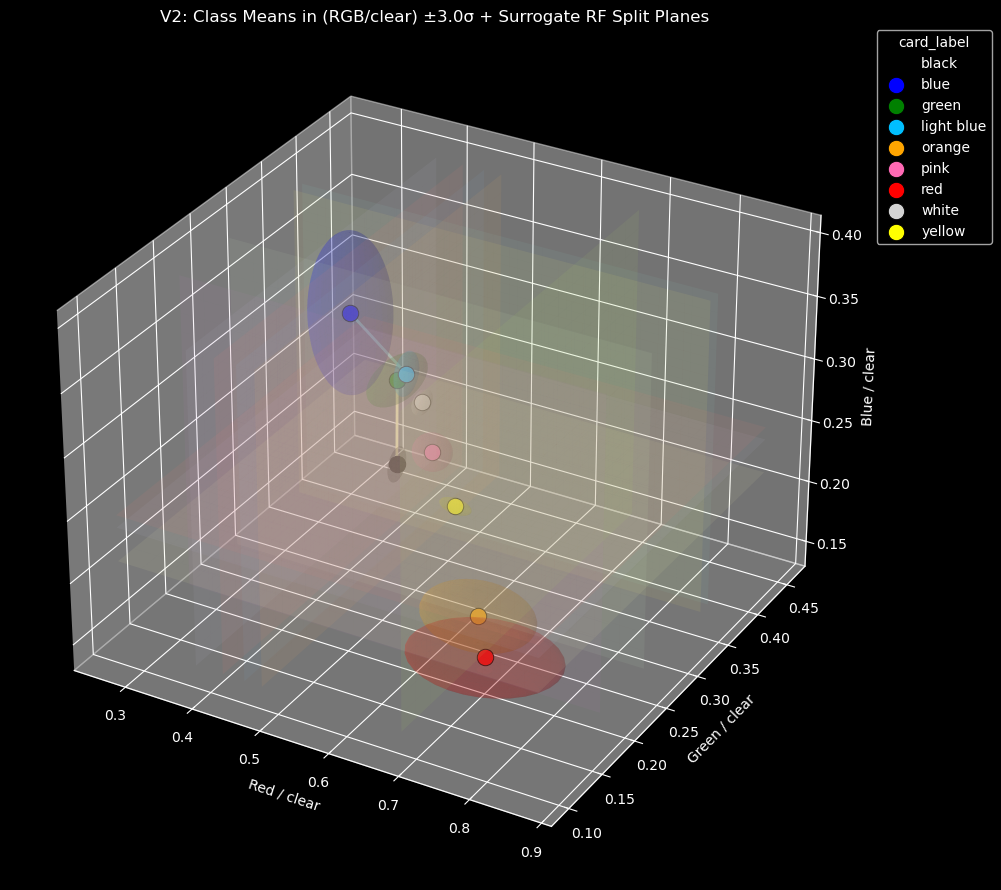

In [25]:
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier

# -----------------------------
# Load V2 data (mode=A) from SQLite
# -----------------------------
db_path = "color_data/color_data.db"
with sqlite3.connect(db_path) as conn:
    df = pd.read_sql_query(
        """
        SELECT card_label, clear, red, green, blue
        FROM colordata_v2
        WHERE mode = 'A'
        """,
        conn
    )

# -----------------------------
# Clean + normalize (same style as before)
# -----------------------------
cols = ["clear", "red", "green", "blue"]
df = df.dropna(subset=cols + ["card_label"]).copy()
for c in cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")
df = df.dropna(subset=cols)
df = df[df["clear"] > 0].copy()

min_clear = 50
df = df[df["clear"] >= min_clear].copy()

# Core chromaticity
df["r_norm"] = df["red"] / df["clear"]
df["g_norm"] = df["green"] / df["clear"]
df["b_norm"] = df["blue"] / df["clear"]

# Extra features used by the latest model (not plotted as axes, but good for surrogate)
df["sum_rgb_norm"] = (df["red"] + df["green"] + df["blue"]) / df["clear"]
df["rg"] = df["r_norm"] - df["g_norm"]
df["bg"] = df["b_norm"] - df["g_norm"]

df["label"] = df["card_label"].astype(str).str.strip().str.lower()

label_to_color = {
    "black": "black",
    "blue": "blue",
    "green": "green",
    "light blue": "deepskyblue",
    "light_blue": "deepskyblue",
    "orange": "orange",
    "pink": "hotpink",
    "red": "red",
    "white": "lightgray",
    "yellow": "yellow",
}

# Mean/std in 3D normalized space (for visualization only)
stats = (
    df.groupby("label")[["r_norm", "g_norm", "b_norm"]]
      .agg(["mean", "std", "count"])
)
stats.columns = ["_".join(c) for c in stats.columns]
stats = stats.reset_index()

def plot_std_ellipsoid(ax, center, radii, color, alpha=0.18, n=32):
    """Draw a 3D axis-aligned ellipsoid centered at `center` with radii `radii`."""
    u = np.linspace(0, 2*np.pi, n)
    v = np.linspace(0, np.pi, n)
    x = radii[0] * np.outer(np.cos(u), np.sin(v)) + center[0]
    y = radii[1] * np.outer(np.sin(u), np.sin(v)) + center[1]
    z = radii[2] * np.outer(np.ones_like(u), np.cos(v)) + center[2]
    ax.plot_surface(x, y, z, color=color, alpha=alpha, linewidth=0, shade=True)

def add_tree_split_planes(ax, clf3d, max_depth_to_show=3, alpha=0.08, n=18):
    """
    Overlay axis-aligned split planes from a DecisionTree on a 3D plot.
    This clf3d MUST be trained on features ordered as [r_norm, g_norm, b_norm].
    """
    if not hasattr(ax, "get_zlim") and not hasattr(ax, "get_zlim3d"):
        raise TypeError("ax is not a 3D axis. Use: ax = fig.add_subplot(111, projection='3d')")

    def _get_zlim(a):
        return a.get_zlim3d() if hasattr(a, "get_zlim3d") else a.get_zlim()

    tree = clf3d.tree_
    feat = tree.feature
    thr = tree.threshold
    left = tree.children_left
    right = tree.children_right

    # Compute node depths so we can draw only top layers
    node_depth = np.zeros(tree.node_count, dtype=int)
    stack = [(0, 0)]
    while stack:
        node_id, depth = stack.pop()
        node_depth[node_id] = depth
        if left[node_id] != right[node_id]:
            stack.append((left[node_id], depth + 1))
            stack.append((right[node_id], depth + 1))

    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()
    z0, z1 = _get_zlim(ax)

    xs = np.linspace(x0, x1, n)
    ys = np.linspace(y0, y1, n)
    zs = np.linspace(z0, z1, n)

    r_thrs, g_thrs, b_thrs = set(), set(), set()
    for i in range(tree.node_count):
        if node_depth[i] > max_depth_to_show:
            continue
        if feat[i] == 0: r_thrs.add(thr[i])  # r_norm
        elif feat[i] == 1: g_thrs.add(thr[i])  # g_norm
        elif feat[i] == 2: b_thrs.add(thr[i])  # b_norm

    # x = const
    Y, Z = np.meshgrid(ys, zs)
    for t in sorted(r_thrs):
        X = np.full_like(Y, t)
        ax.plot_surface(X, Y, Z, alpha=alpha, linewidth=0, shade=False)

    # y = const
    X, Z = np.meshgrid(xs, zs)
    for t in sorted(g_thrs):
        Y = np.full_like(X, t)
        ax.plot_surface(X, Y, Z, alpha=alpha, linewidth=0, shade=False)

    # z = const
    X, Y = np.meshgrid(xs, ys)
    for t in sorted(b_thrs):
        Z = np.full_like(X, t)
        ax.plot_surface(X, Y, Z, alpha=alpha, linewidth=0, shade=False)

# -----------------------------
# Build a surrogate tree to approximate the RandomForest behaviour
# -----------------------------
# We fit a small decision tree to mimic rf.predict(...) on the SAME V2 points,
# then draw that surrogate tree's split planes in (r_norm,g_norm,b_norm) space.
# This gives you a "single if/else" style visual summary of the RF.
if "rf" not in globals():
    raise NameError("rf not found. Please run the latest RandomForest training cell first.")

FEATURES = ["r_norm", "g_norm", "b_norm", "sum_rgb_norm", "rg", "bg"]
X6 = df[FEATURES].to_numpy()
y_rf = rf.predict(X6)  # pseudo-labels = RF decisions

# Surrogate tree uses only 3D features (for split plane visualization)
X3 = df[["r_norm", "g_norm", "b_norm"]].to_numpy()
sur = DecisionTreeClassifier(max_depth=4, min_samples_leaf=30, random_state=42)
sur.fit(X3, y_rf)

# -----------------------------
# 3D plot
# -----------------------------
plt.style.use("dark_background")
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection="3d")

k_sigma = 3.0

# Draw class centers + envelopes
centers = {}
for _, row in stats.iterrows():
    label = row["label"]
    c = label_to_color.get(label, "gray")

    center = np.array([row["r_norm_mean"], row["g_norm_mean"], row["b_norm_mean"]], dtype=float)
    radii  = np.array([row["r_norm_std"],  row["g_norm_std"],  row["b_norm_std"]], dtype=float) * k_sigma
    centers[label] = center

    ax.scatter(center[0], center[1], center[2],
               s=140, c=c, edgecolors="k", linewidths=0.7, label=label)

    if np.all(np.isfinite(radii)) and np.all(radii > 0):
        plot_std_ellipsoid(ax, center, radii, c, alpha=0.18, n=32)

# Highlight the known confusion pairs (from your latest results)
def connect(lbl1, lbl2, color="white"):
    if lbl1 in centers and lbl2 in centers:
        a, b = centers[lbl1], centers[lbl2]
        ax.plot([a[0], b[0]], [a[1], b[1]], [a[2], b[2]], linewidth=2.0, alpha=0.9)

connect("light blue", "blue", color="white")
connect("black", "green", color="white")

ax.set_title(f"V2: Class Means in (RGB/clear) ±{k_sigma:.1f}σ + Surrogate RF Split Planes")
ax.set_xlabel("Red / clear")
ax.set_ylabel("Green / clear")
ax.set_zlabel("Blue / clear")
ax.grid(True, linewidth=0.4, alpha=0.25)

# Overlay surrogate tree split planes (approximate RF decision structure)
add_tree_split_planes(ax, sur, max_depth_to_show=3, alpha=0.08, n=18)

ax.legend(title="card_label", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.show()

In [26]:
import sqlite3
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

db_path = "color_data/color_data.db"

def load_table(table_name: str, mode: str = "A") -> pd.DataFrame:
    with sqlite3.connect(db_path) as conn:
        return pd.read_sql_query(
            f"""
            SELECT clear, red, green, blue, card_label
            FROM {table_name}
            WHERE mode = ?
            """,
            conn,
            params=(mode,),
        )

def preprocess(df: pd.DataFrame, min_clear: int = 20) -> pd.DataFrame:
    cols = ["clear", "red", "green", "blue"]
    df = df.dropna(subset=cols + ["card_label"]).copy()
    for c in cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.dropna(subset=cols)

    df = df[df["clear"] > 0].copy()
    df = df[df["clear"] >= min_clear].copy()

    # Chromaticity features
    df["r_norm"] = df["red"] / df["clear"]
    df["g_norm"] = df["green"] / df["clear"]
    df["b_norm"] = df["blue"] / df["clear"]

    # Extra discriminative features (still stable)
    df["sum_rgb_norm"] = (df["red"] + df["green"] + df["blue"]) / df["clear"]
    df["rg"] = df["r_norm"] - df["g_norm"]
    df["bg"] = df["b_norm"] - df["g_norm"]

    df["label"] = df["card_label"].astype(str).str.strip().str.lower()
    return df

def misclass_summary(group_df: pd.DataFrame) -> str:
    wrong = group_df[group_df["label"] != group_df["pred"]]
    if wrong.empty:
        return ""
    vc = wrong["pred"].value_counts()
    return ", ".join([f"{k}:{v}" for k, v in vc.items()])

# -----------------------------
# 1) Load + merge V1 and V2
# -----------------------------
MIN_CLEAR_DATASET = 20
v1 = preprocess(load_table("color_data", mode="A"), min_clear=MIN_CLEAR_DATASET)
v2 = preprocess(load_table("colordata_v2", mode="A"), min_clear=MIN_CLEAR_DATASET)
all_df = pd.concat([v1.assign(source="v1"), v2.assign(source="v2")], ignore_index=True)

print("Merged label counts:")
print(all_df["label"].value_counts())

# Feature set (expanded)
FEATURES = ["r_norm", "g_norm", "b_norm", "sum_rgb_norm", "rg", "bg"]
X = all_df[FEATURES].to_numpy()
y = all_df["label"].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# -----------------------------
# 2) Train Random Forest (teacher model)
# -----------------------------
rf = RandomForestClassifier(
    n_estimators=600,
    max_depth=None,
    min_samples_leaf=1,
    min_samples_split=2,
    max_features="sqrt",
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# RF baseline
rf_pred = rf.predict(X_test)
print("\n[RF] Overall test accuracy:", accuracy_score(y_test, rf_pred))

rf_eval = pd.DataFrame({"label": y_test, "pred": rf_pred})
rf_results = (
    rf_eval.assign(correct=(rf_eval["label"] == rf_eval["pred"]).astype(int))
           .groupby("label")
           .agg(
               total=("correct", "size"),
               correct=("correct", "sum"),
               accuracy=("correct", "mean"),
               misclassified_as=("pred", lambda s: misclass_summary(rf_eval.loc[s.index])),
           )
           .sort_values("accuracy", ascending=False)
)
display(rf_results)

# -----------------------------
# 3) Train a surrogate tree to mimic the RF (student model)
#    IMPORTANT: train surrogate on X_train and RF labels (not true labels)
# -----------------------------
y_train_rf = rf.predict(X_train)

sur = DecisionTreeClassifier(
    max_depth=6,          # adjust: smaller => shorter C code, larger => closer to RF
    min_samples_leaf=20,  # adjust: larger => smoother / less overfit
    random_state=42
)
sur.fit(X_train, y_train_rf)

# Evaluate surrogate against TRUE labels on the same test set
sur_pred = sur.predict(X_test)
print("\n[Surrogate Tree] Overall test accuracy:", accuracy_score(y_test, sur_pred))

sur_eval = pd.DataFrame({"label": y_test, "pred": sur_pred})
sur_results = (
    sur_eval.assign(correct=(sur_eval["label"] == sur_eval["pred"]).astype(int))
           .groupby("label")
           .agg(
               total=("correct", "size"),
               correct=("correct", "sum"),
               accuracy=("correct", "mean"),
               misclassified_as=("pred", lambda s: misclass_summary(sur_eval.loc[s.index])),
           )
           .sort_values("accuracy", ascending=False)
)
display(sur_results)

# Optional: how well the surrogate matches the RF itself on the test set
print("[Surrogate Tree] Agreement with RF on test:",
      np.mean(sur_pred == rf_pred))

Merged label counts:
label
green         1500
orange        1500
pink          1500
red           1500
yellow        1499
black         1498
light blue    1498
blue          1497
white         1497
Name: count, dtype: int64

[RF] Overall test accuracy: 0.9991105840498073


,total,correct,accuracy,misclassified_as
label,,,,
blue,374,374,1.000000,
green,375,375,1.000000,
orange,375,375,1.000000,
pink,375,375,1.000000,
red,375,375,1.000000,
white,374,374,1.000000,
yellow,375,375,1.000000,
light blue,375,374,0.997333,blue:1
black,375,373,0.994667,green:2



[Surrogate Tree] Overall test accuracy: 0.9952564482656389


,total,correct,accuracy,misclassified_as
label,,,,
blue,374,374,1.000000,
yellow,375,375,1.000000,
orange,375,374,0.997333,red:1
pink,375,374,0.997333,blue:1
red,375,374,0.997333,pink:1
white,374,373,0.997326,blue:1
light blue,375,372,0.992000,blue:3
black,375,371,0.989333,"white:2, green:2"
green,375,370,0.986667,black:5


[Surrogate Tree] Agreement with RF on test: 0.9961458642158316


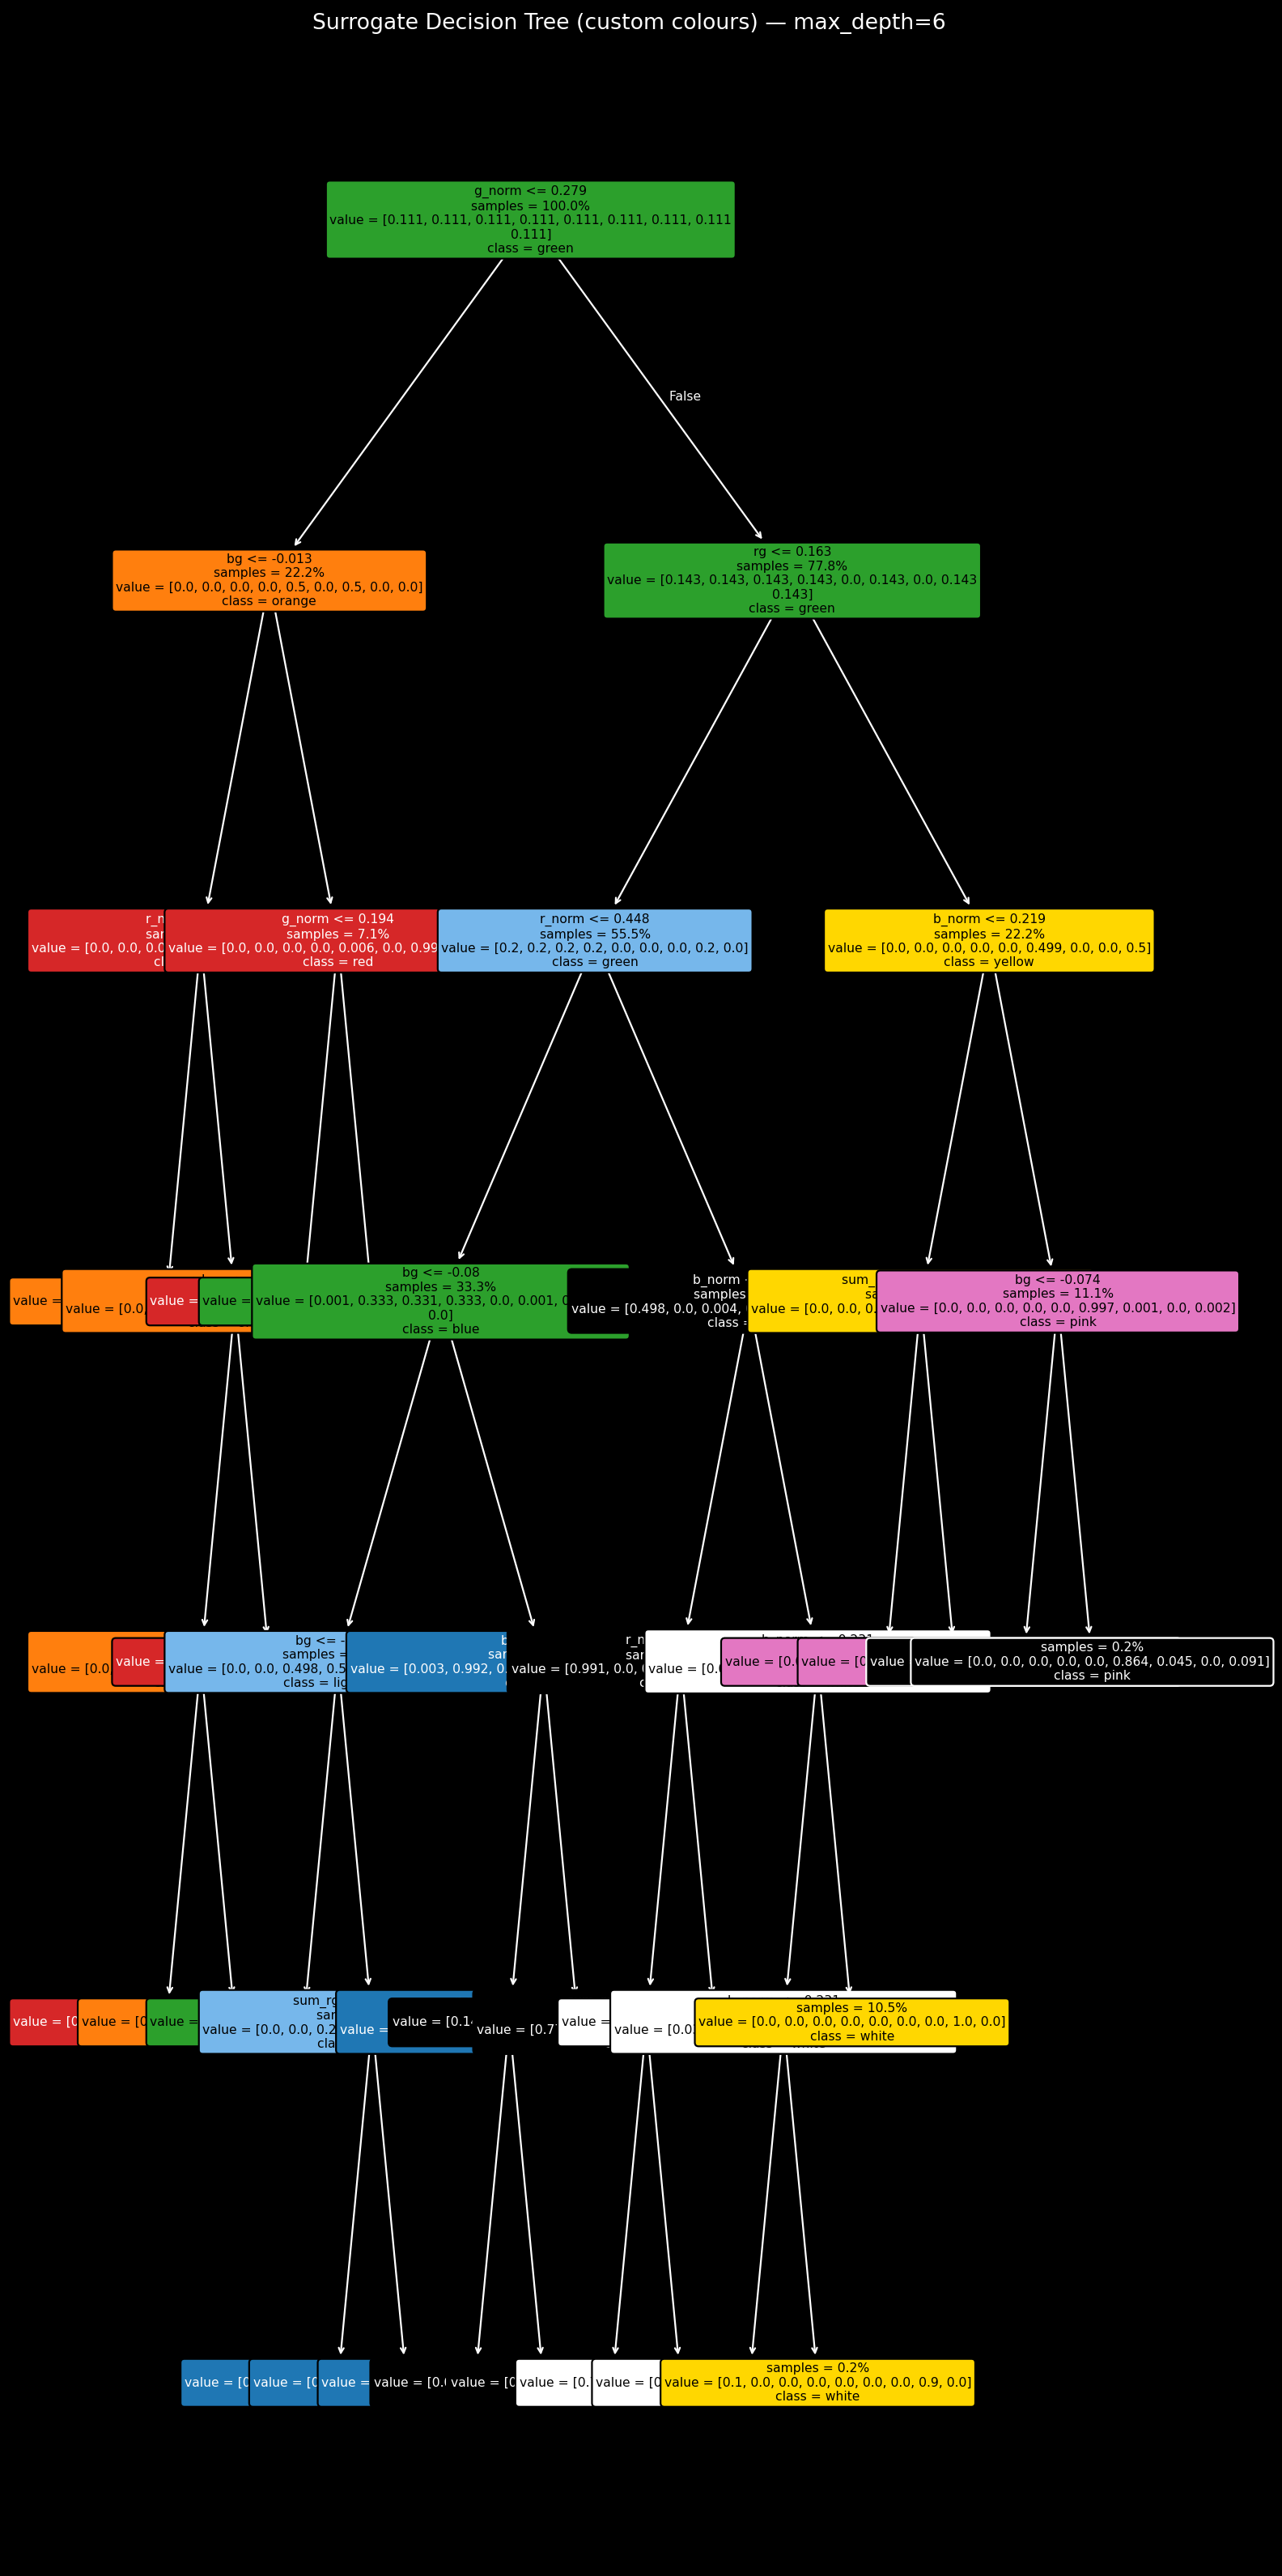

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Fixed label -> colour mapping (edit hex if you want different shades)
LABEL_TO_COLOR = {
    "black": "#000000",
    "blue": "#1f77b4",
    "green": "#2ca02c",
    "light blue": "#76b7eb",
    "orange": "#ff7f0e",
    "pink": "#e377c2",
    "red": "#d62728",
    "white": "#ffffff",
    "yellow": "#ffd700",
    # fallback if there are unexpected labels:
    "unknown": "#cccccc",
}

def recolor_tree_nodes(ax, tree_model, label_to_color):
    """
    Recolor node boxes according to the predicted class at each node.
    Works reliably by editing bbox patches of the Text artists returned by plot_tree.
    """
    tree = tree_model.tree_
    texts = ax.texts  # plot_tree adds node text artists here
    n_nodes = tree.node_count
    n = min(len(texts), n_nodes)

    # Helper: decide if we should use white text on this background
    def is_dark(hex_color: str) -> bool:
        hex_color = hex_color.lstrip("#")
        if len(hex_color) != 6:
            return False
        r = int(hex_color[0:2], 16)
        g = int(hex_color[2:4], 16)
        b = int(hex_color[4:6], 16)
        # perceived luminance
        lum = 0.2126 * r + 0.7152 * g + 0.0722 * b
        return lum < 110

    for node_id in range(n):
        cls_id = int(np.argmax(tree.value[node_id][0]))
        label = str(tree_model.classes_[cls_id]).strip().lower()

        face = label_to_color.get(label, label_to_color.get("unknown", "#cccccc"))

        t = texts[node_id]
        bbox = t.get_bbox_patch()
        if bbox is not None:
            bbox.set_facecolor(face)
            bbox.set_edgecolor("#000000")
            bbox.set_linewidth(1.0)

        t.set_color("white" if is_dark(face) else "black")

# --- Plot (vertical) ---
MAX_DEPTH = 6  # reduce to 4~5 if it gets too crowded

fig, ax = plt.subplots(figsize=(10, 20), dpi=160)

# Draw without filled colours first (we will apply our own)
plot_tree(
    sur,
    feature_names=FEATURES,
    class_names=sur.classes_,
    filled=False,
    rounded=True,
    impurity=False,
    proportion=True,
    fontsize=7,
    max_depth=MAX_DEPTH,
    ax=ax
)

# Apply your label colours
recolor_tree_nodes(ax, sur, LABEL_TO_COLOR)

ax.set_title(f"Surrogate Decision Tree (custom colours) — max_depth={MAX_DEPTH}")
fig.tight_layout()
fig.savefig("surrogate_tree_vertical_coloured.png", dpi=300, bbox_inches="tight")
plt.show()

In [33]:
import sqlite3
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# ============================================================
# C code generator for the SURROGATE TREE (drop-in replacement)
# ============================================================
# Goal:
# - Keep your firmware interfaces unchanged:
#     * ColorClass enum stays the same IDs (0..8 in your existing order)
#     * predict_color_rgba_u32(uint32_t R,G,B,C) signature stays the same
#     * color_to_string(...) stays the same
# - Only replace the "auto-generated middle section":
#     constants + MEAN/STD arrays + gate + tree_predict_class_id()
# - The tree itself is trained only on (R/C, G/C, B/C) so it doesn't split on clear.
#
# NOTE: This generator assumes your ColorClass IDs are fixed to:
#   0 black, 1 blue, 2 green, 3 light blue, 4 orange, 5 pink, 6 red, 7 white, 8 yellow
# If your firmware uses a different order, update CLASS_ORDER below.

CLASS_ORDER = ["black","blue","green","light blue","orange","pink","red","white","yellow"]
CLASS_TO_ID = {c:i for i,c in enumerate(CLASS_ORDER)}

SCALE = 100000
MIN_CLEAR_RUNTIME = 50          # runtime "no card" threshold in firmware
EPS_STD = 300                   # std floor (fixed-point units) for stable Mahalanobis
K_SIGMA = 2.5                   # controls MAHA_THR (~ 3*K^2)

def load_v2(mode="A"):
    db_path = "color_data/color_data.db"
    with sqlite3.connect(db_path) as conn:
        df = pd.read_sql_query(
            """
            SELECT clear, red, green, blue, card_label
            FROM colordata_v2
            WHERE mode = ?
            """,
            conn, params=(mode,)
        )
    return df

def clean_and_features(df, min_clear_train=20):
    df = df.dropna(subset=["clear","red","green","blue","card_label"]).copy()
    for c in ["clear","red","green","blue"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.dropna(subset=["clear","red","green","blue"])
    df = df[df["clear"] > 0].copy()
    df = df[df["clear"] >= min_clear_train].copy()

    # Normalize
    df["r_norm"] = df["red"] / df["clear"]
    df["g_norm"] = df["green"] / df["clear"]
    df["b_norm"] = df["blue"] / df["clear"]

    # Extra features used by your best RF
    df["sum_rgb_norm"] = (df["red"] + df["green"] + df["blue"]) / df["clear"]
    df["rg"] = df["r_norm"] - df["g_norm"]
    df["bg"] = df["b_norm"] - df["g_norm"]

    df["label"] = df["card_label"].astype(str).str.strip().str.lower()
    # keep only known labels
    df = df[df["label"].isin(CLASS_TO_ID.keys())].copy()
    return df

def train_surrogate_tree(df, max_depth=6, min_samples_leaf=20):
    """
    Train a surrogate decision tree using 3D features (r_norm,g_norm,b_norm).
    The target is the TRUE label (not RF teacher) so deployment matches your labels.
    This is the simplest C-portable surrogate.
    """
    X = df[["r_norm","g_norm","b_norm"]].to_numpy()
    y = df["label"].map(CLASS_TO_ID).to_numpy()  # fixed IDs

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y
    )

    clf = DecisionTreeClassifier(
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        random_state=42
    )
    clf.fit(X_train, y_train)

    acc = (clf.predict(X_test) == y_test).mean()
    return clf, acc

def compute_stats_fixed(df):
    """
    Compute mean/std of (r_norm,g_norm,b_norm) per fixed class ID, output fixed-point ints.
    """
    df2 = df.copy()
    df2["cid"] = df2["label"].map(CLASS_TO_ID).astype(int)

    stats = (
        df2.groupby("cid")[["r_norm","g_norm","b_norm"]]
           .agg(["mean","std"])
    )
    stats.columns = ["_".join(c) for c in stats.columns]
    stats = stats.reset_index()

    mean_r = [0]*len(CLASS_ORDER)
    mean_g = [0]*len(CLASS_ORDER)
    mean_b = [0]*len(CLASS_ORDER)
    std_r  = [0]*len(CLASS_ORDER)
    std_g  = [0]*len(CLASS_ORDER)
    std_b  = [0]*len(CLASS_ORDER)

    def to_fixed(x): return int(round(float(x)*SCALE))

    for _, row in stats.iterrows():
        i = int(row["cid"])
        mean_r[i] = to_fixed(row["r_norm_mean"])
        mean_g[i] = to_fixed(row["g_norm_mean"])
        mean_b[i] = to_fixed(row["b_norm_mean"])
        std_r[i]  = to_fixed(row["r_norm_std"]) if np.isfinite(row["r_norm_std"]) else 0
        std_g[i]  = to_fixed(row["g_norm_std"]) if np.isfinite(row["g_norm_std"]) else 0
        std_b[i]  = to_fixed(row["b_norm_std"]) if np.isfinite(row["b_norm_std"]) else 0

    return mean_r, mean_g, mean_b, std_r, std_g, std_b

def emit_u32_array(name, arr):
    return "static const uint32_t " + name + "[] = {" + ", ".join(str(int(x)) for x in arr) + "};\n"

def emit_tree_as_c(clf):
    """
    Emit tree_predict_class_id() using ONLY R/C, G/C, B/C comparisons (no clear splits).
    We convert thresholds on r_norm,g_norm,b_norm into cross-multiply integer comparisons:
        (R * SCALE) <= (T * C)
    """
    tree = clf.tree_
    LEFT, RIGHT = tree.children_left, tree.children_right
    FEATURE, THRESH, VALUE = tree.feature, tree.threshold, tree.value
    feat_names = ["r_norm","g_norm","b_norm"]

    def is_leaf(n): return LEFT[n] == RIGHT[n]
    def leaf_id(n): return int(np.argmax(VALUE[n][0]))  # because y was ints 0..8

    def emit_node(n, indent=2):
        sp = " " * indent
        if is_leaf(n):
            return f"{sp}return {leaf_id(n)};\n"

        f_idx = int(FEATURE[n])
        thr = float(THRESH[n])               # threshold in float r_norm space
        T = int(round(thr * SCALE))          # fixed-point threshold

        num = "R" if feat_names[f_idx] == "r_norm" else ("G" if feat_names[f_idx] == "g_norm" else "B")

        s = ""
        s += f"{sp}if (((uint64_t){num} * {SCALE}ULL) <= ((uint64_t){T}ULL * (uint64_t)C)) {{\n"
        s += emit_node(int(LEFT[n]), indent+2)
        s += f"{sp}}} else {{\n"
        s += emit_node(int(RIGHT[n]), indent+2)
        s += f"{sp}}}\n"
        return s

    out = "static inline int tree_predict_class_id(uint32_t R, uint32_t G, uint32_t B, uint32_t C) {\n"
    out += emit_node(0, indent=2)
    out += "}\n"
    return out

def generate_c_block_surrogate(clf, mean_r, mean_g, mean_b, std_r, std_g, std_b):
    maha_thr = int(round(3.0 * (K_SIGMA**2) * 1000.0))

    c = ""
    c += "/* ===== AUTO-GENERATED BLOCK (SURROGATE TREE + MAHA GATE) ===== */\n"
    c += "#include <stdint.h>\n"
    c += "#include <stddef.h>\n\n"
    c += f"static const uint32_t MIN_CLEAR = {int(MIN_CLEAR_RUNTIME)}u;\n"
    c += f"static const uint32_t SCALE = {int(SCALE)}u;\n"
    c += f"static const uint32_t EPS_STD = {int(EPS_STD)}u;\n"
    c += f"static const uint32_t MAHA_THR_X1000 = {int(maha_thr)}u;\n\n"
    c += emit_u32_array("MEAN_R", mean_r)
    c += emit_u32_array("MEAN_G", mean_g)
    c += emit_u32_array("MEAN_B", mean_b)
    c += emit_u32_array("STD_R", std_r)
    c += emit_u32_array("STD_G", std_g)
    c += emit_u32_array("STD_B", std_b)
    c += "\n"
    c += "static inline uint32_t uabs_diff_u32(uint32_t a, uint32_t b) {\n"
    c += "  return (a >= b) ? (a - b) : (b - a);\n"
    c += "}\n\n"
    c += "static inline uint32_t clamp_std(uint32_t s) {\n"
    c += "  return (s < EPS_STD) ? EPS_STD : s;\n"
    c += "}\n\n"
    c += "static inline int passes_maha_gate(uint32_t rS, uint32_t gS, uint32_t bS, uint32_t cls) {\n"
    c += "  uint32_t dr = uabs_diff_u32(rS, MEAN_R[cls]);\n"
    c += "  uint32_t dg = uabs_diff_u32(gS, MEAN_G[cls]);\n"
    c += "  uint32_t db = uabs_diff_u32(bS, MEAN_B[cls]);\n"
    c += "  uint32_t sr = clamp_std(STD_R[cls]);\n"
    c += "  uint32_t sg = clamp_std(STD_G[cls]);\n"
    c += "  uint32_t sb = clamp_std(STD_B[cls]);\n"
    c += "  uint64_t dr2 = (uint64_t)dr * (uint64_t)dr;\n"
    c += "  uint64_t dg2 = (uint64_t)dg * (uint64_t)dg;\n"
    c += "  uint64_t db2 = (uint64_t)db * (uint64_t)db;\n"
    c += "  uint64_t sr2 = (uint64_t)sr * (uint64_t)sr;\n"
    c += "  uint64_t sg2 = (uint64_t)sg * (uint64_t)sg;\n"
    c += "  uint64_t sb2 = (uint64_t)sb * (uint64_t)sb;\n"
    c += "  uint64_t t_r = (dr2 * 1000ULL) / sr2;\n"
    c += "  uint64_t t_g = (dg2 * 1000ULL) / sg2;\n"
    c += "  uint64_t t_b = (db2 * 1000ULL) / sb2;\n"
    c += "  uint64_t D_x1000 = t_r + t_g + t_b;\n"
    c += "  return (D_x1000 <= (uint64_t)MAHA_THR_X1000) ? 1 : 0;\n"
    c += "}\n\n"
    c += emit_tree_as_c(clf)
    c += "/* ===== END AUTO-GENERATED BLOCK ===== */\n"
    return c

# -----------------------------
# RUN: train surrogate + emit C
# -----------------------------
raw = load_v2(mode="A")
data = clean_and_features(raw, min_clear_train=20)

sur_clf, sur_acc = train_surrogate_tree(data, max_depth=6, min_samples_leaf=20)
print("Surrogate tree test accuracy (25% split):", sur_acc)

mean_r, mean_g, mean_b, std_r, std_g, std_b = compute_stats_fixed(data)

c_block = generate_c_block_surrogate(sur_clf, mean_r, mean_g, mean_b, std_r, std_g, std_b)

print("\n===== GENERATED C AUTO-BLOCK (SURROGATE TREE) =====\n")
print(c_block)

Surrogate tree test accuracy (25% split): 0.9955555555555555

===== GENERATED C AUTO-BLOCK (SURROGATE TREE) =====

/* ===== AUTO-GENERATED BLOCK (SURROGATE TREE + MAHA GATE) ===== */
#include <stdint.h>
#include <stddef.h>

static const uint32_t MIN_CLEAR = 50u;
static const uint32_t SCALE = 100000u;
static const uint32_t EPS_STD = 300u;
static const uint32_t MAHA_THR_X1000 = 18750u;

static const uint32_t MEAN_R[] = {45669, 36092, 37749, 42469, 68137, 51151, 72686, 46071, 55081};
static const uint32_t MEAN_G[] = {31552, 34308, 39590, 36288, 20909, 31432, 17208, 35028, 30942};
static const uint32_t MEAN_B[] = {21973, 31501, 23981, 26667, 18444, 23863, 17807, 25465, 20280};
static const uint32_t STD_R[] = {578, 1887, 965, 353, 2630, 899, 3485, 324, 794};
static const uint32_t STD_G[] = {455, 1056, 1243, 548, 1104, 489, 1644, 429, 74};
static const uint32_t STD_B[] = {817, 2153, 503, 575, 716, 466, 336, 308, 220};

static inline uint32_t uabs_diff_u32(uint32_t a, uint32_t b) {
  return (

In [34]:
from sklearn.tree import export_text

# Prints the surrogate tree as readable if/else rules
tree_text = export_text(
    sur,
    feature_names=FEATURES,  # e.g. ["r_norm","g_norm","b_norm","sum_rgb_norm","rg","bg"]
    decimals=5
)
print(tree_text)

|--- g_norm <= 0.27949
|   |--- bg <= -0.01342
|   |   |--- r_norm <= 0.49415
|   |   |   |--- class: red
|   |   |--- r_norm >  0.49415
|   |   |   |--- sum_rgb_norm <= 1.05377
|   |   |   |   |--- rg <= 0.40738
|   |   |   |   |   |--- class: orange
|   |   |   |   |--- rg >  0.40738
|   |   |   |   |   |--- class: red
|   |   |   |--- sum_rgb_norm >  1.05377
|   |   |   |   |--- class: orange
|   |--- bg >  -0.01342
|   |   |--- g_norm <= 0.19391
|   |   |   |--- class: red
|   |   |--- g_norm >  0.19391
|   |   |   |--- class: red
|--- g_norm >  0.27949
|   |--- rg <= 0.16340
|   |   |--- r_norm <= 0.44819
|   |   |   |--- bg <= -0.08022
|   |   |   |   |--- bg <= -0.11555
|   |   |   |   |   |--- class: green
|   |   |   |   |--- bg >  -0.11555
|   |   |   |   |   |--- sum_rgb_norm <= 0.97518
|   |   |   |   |   |   |--- class: green
|   |   |   |   |   |--- sum_rgb_norm >  0.97518
|   |   |   |   |   |   |--- class: light blue
|   |   |   |--- bg >  -0.08022
|   |   |   |   |--- 